# Modelling - ARIMA Models

This notebook goes through the different steps of selecting the best ARIMA model for footfall prediction. The notebook is based on the following GitHub repository: [GitHub Repo](https://github.com/MKB-Datalab/time-series-analysis-with-SARIMAX-and-Prophet/blob/e3b47dff8994965ebde376f07aa70280267adb72/notebooks/02-Forecasting_with_SARIMAX.ipynb)

In [73]:
pip install matplotlib geopandas numpy scikit-learn statsmodels seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [74]:
#Import packages
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import seaborn as sns
import scipy

In [ ]:
#Load training footfall (2019-2024) data
data = pd.read_csv(r"footfall_cleaned_19_24")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2192 non-null   int64  
 1   datestamp                          2192 non-null   object 
 2   estimated_actual_footfall          2192 non-null   float64
 3   estimated_actual_footfall_rolling  2192 non-null   int64  
 4   year                               2192 non-null   int64  
 5   month                              2192 non-null   int64  
 6   monthday                           2192 non-null   int64  
 7   weekday                            2192 non-null   int64  
 8   week_of_year                       2192 non-null   int64  
 9   Sin_weekday                        2192 non-null   float64
 10  Cos_weekday                        2192 non-null   float64
 11  Sin_monthday                       2192 non-null   float

In [76]:
#Keep only the columns of interest for analysis
data = data[['datestamp',
             'estimated_actual_footfall', 
             'bank_hol', 
             'school_hol', 
             'covid', 
             'temperature_2m_mean', 
             'precipitation_sum', 
             'wind_speed_10m_max', 
             'daylight_duration']]
#Set the datestamp as the datetime
data['datestamp'] = pd.to_datetime(data['datestamp'])
data.head()

,datestamp,estimated_actual_footfall,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,2019-01-01,530996.0,1,1,0,6.158333,0.0,24.490587,27067.838
1,2019-01-02,568621.0,0,1,0,2.304167,0.0,10.086427,27147.844
2,2019-01-03,606939.0,0,1,0,0.387500,0.0,6.479999,27235.123
3,2019-01-04,508695.0,0,1,0,2.064583,0.0,15.629971,27329.416
4,2019-01-05,468546.0,0,0,0,3.768750,0.0,14.168641,27430.486


## Step 1: Time Series EDA

In [77]:
#Create some time related columns
data['year'] = data['datestamp'].dt.year
data['month'] = data['datestamp'].dt.month
data['day'] = data['datestamp'].dt.dayofyear
data['weekday'] = data['datestamp'].dt.weekday
data['year-month'] = data['datestamp'].apply(lambda x: str(x.year)+'-'+str(x.month))

<Axes: title={'center': 'Footfall per week day.'}, xlabel='weekday', ylabel='estimated_actual_footfall'>

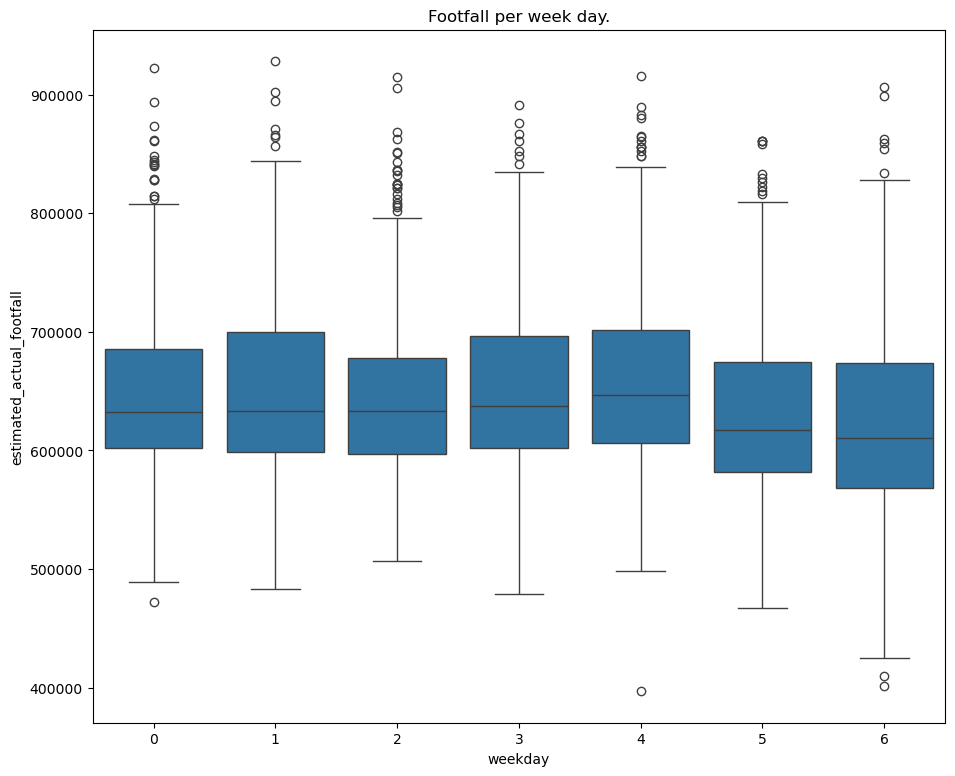

In [78]:
plt.title("Footfall per week day.")
sns.boxplot(x="weekday", y="estimated_actual_footfall", data=data)

<Axes: title={'center': 'Footfall per month.'}, xlabel='month', ylabel='estimated_actual_footfall'>

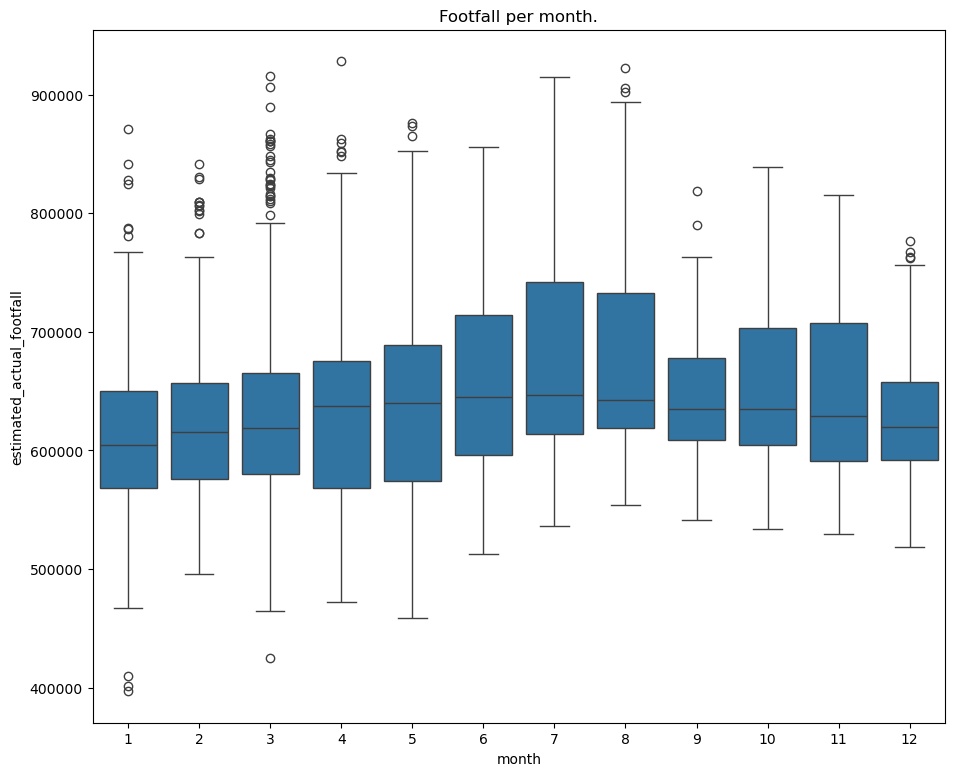

In [79]:
plt.title("Footfall per month.")
sns.boxplot(x="month", y="estimated_actual_footfall", data=data)

<Axes: title={'center': 'Footfall per Year-Month'}, xlabel='year-month', ylabel='estimated_actual_footfall'>

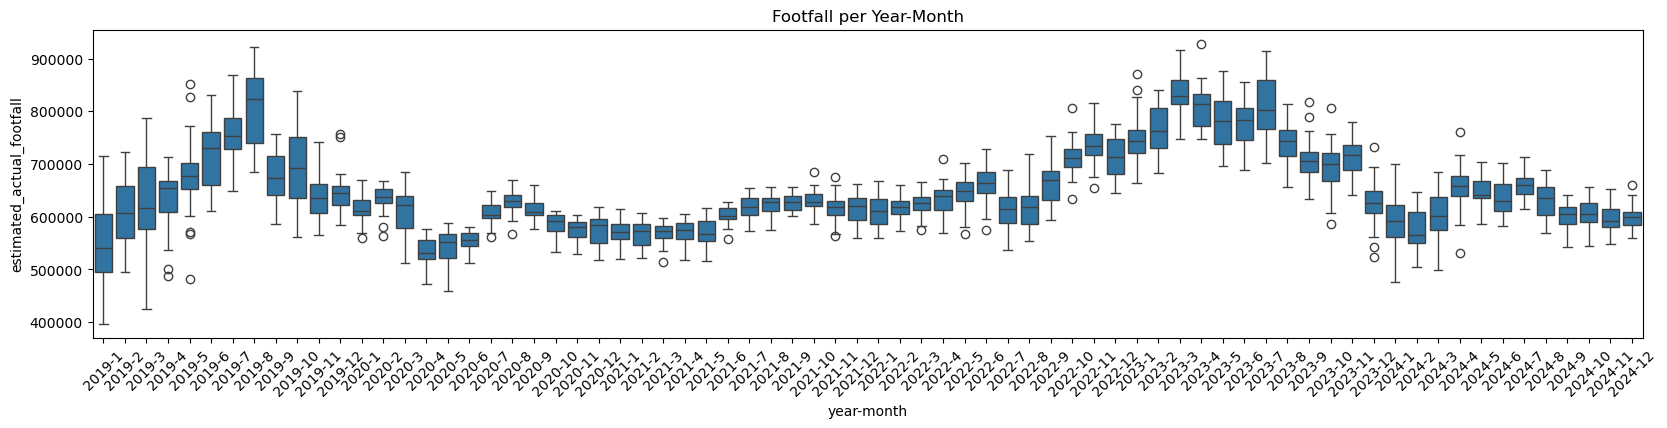

In [80]:
plt.figure(figsize=(20,4))
plt.xticks(rotation=45)
plt.title('Footfall per Year-Month')
sns.boxplot(x="year-month", y="estimated_actual_footfall", data=data)

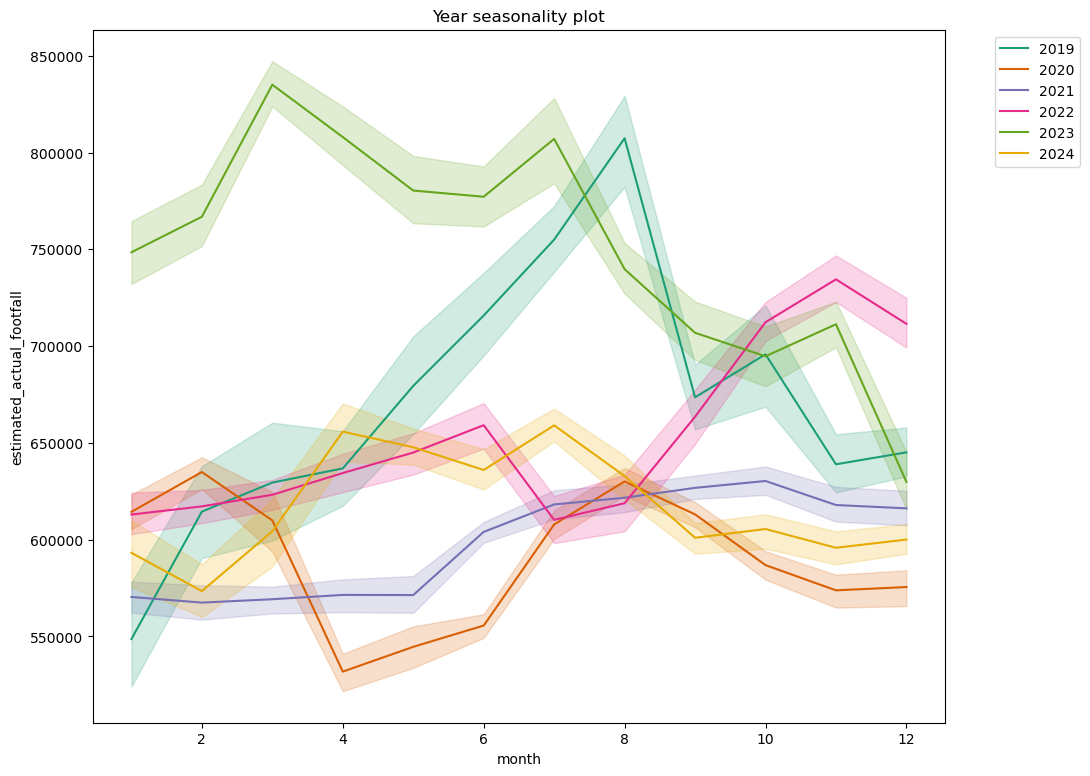

In [81]:
sns.lineplot(data=data, 
             x='month', 
             y='estimated_actual_footfall', 
             hue='year', 
             legend='full',
            palette='Dark2')

# add title
plt.title('Year seasonality plot')

# move the legend outside of the main figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2);

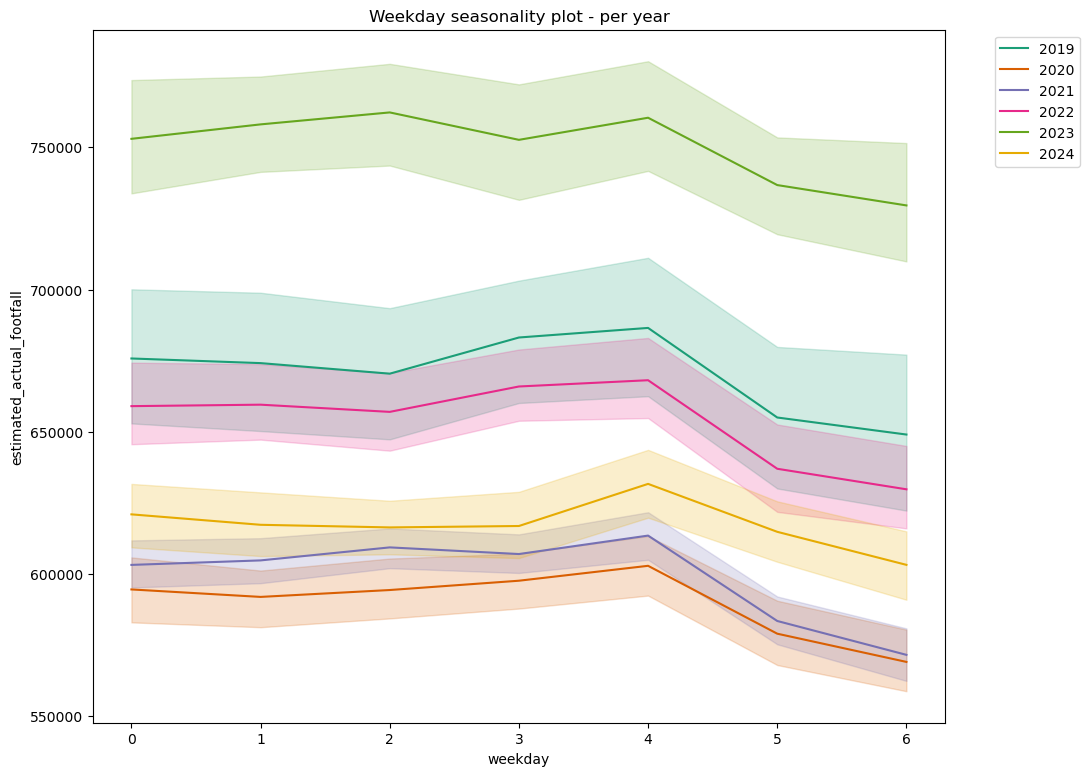

In [82]:
sns.lineplot(data=data, 
             x='weekday', 
             y='estimated_actual_footfall', 
             hue='year', 
             legend='full',
            palette='Dark2')

# add title
plt.title('Weekday seasonality plot - per year')

# move the legend outside of the main figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2);

## Step 2: Identify properties of time series

There are several properties of the time series that need to be identified before being able to build an ARIMA model:
* **Trend:** ARIMA can only model trends if data is differenced
* **Seasonality:** is time series seasonal or cyclical? -> if seasonal need SARIMA not ARIMA
* If seasonal, what is the seasonal period?
* **Stationarity:** is time series stationary or not ? -> ARIMA assumes stationarity
* If no stationary, which transformation should be applied to make it stationary?
* Whether time series is additive or multiplicative

In [ ]:
#Load training footfall (2019-2024) data again
data = pd.read_csv(r"footfall_cleaned_19_24")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2192 non-null   int64  
 1   datestamp                          2192 non-null   object 
 2   estimated_actual_footfall          2192 non-null   float64
 3   estimated_actual_footfall_rolling  2192 non-null   int64  
 4   year                               2192 non-null   int64  
 5   month                              2192 non-null   int64  
 6   monthday                           2192 non-null   int64  
 7   weekday                            2192 non-null   int64  
 8   week_of_year                       2192 non-null   int64  
 9   Sin_weekday                        2192 non-null   float64
 10  Cos_weekday                        2192 non-null   float64
 11  Sin_monthday                       2192 non-null   float

In [84]:
#Keep only the columns of interest for analysis
data = data[['datestamp',
             'estimated_actual_footfall', 
             'bank_hol', 
             'school_hol', 
             'covid', 
             'temperature_2m_mean', 
             'precipitation_sum', 
             'wind_speed_10m_max', 
             'daylight_duration']]
#Set the datestamp as the index
data['datestamp'] = pd.to_datetime(data['datestamp'])
data.set_index('datestamp', inplace=True)
data.head()

,estimated_actual_footfall,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
datestamp,,,,,,,,
2019-01-01,530996.0,1,1,0,6.158333,0.0,24.490587,27067.838
2019-01-02,568621.0,0,1,0,2.304167,0.0,10.086427,27147.844
2019-01-03,606939.0,0,1,0,0.387500,0.0,6.479999,27235.123
2019-01-04,508695.0,0,1,0,2.064583,0.0,15.629971,27329.416
2019-01-05,468546.0,0,0,0,3.768750,0.0,14.168641,27430.486


In [85]:
#Separate the X and Y variables

Y = data[['estimated_actual_footfall']] #target variable

X = data[['bank_hol', 
             'school_hol', 
             'covid', 
             'temperature_2m_mean', 
             'precipitation_sum', 
             'wind_speed_10m_max', 
             'daylight_duration']] #predictor exogenous variables

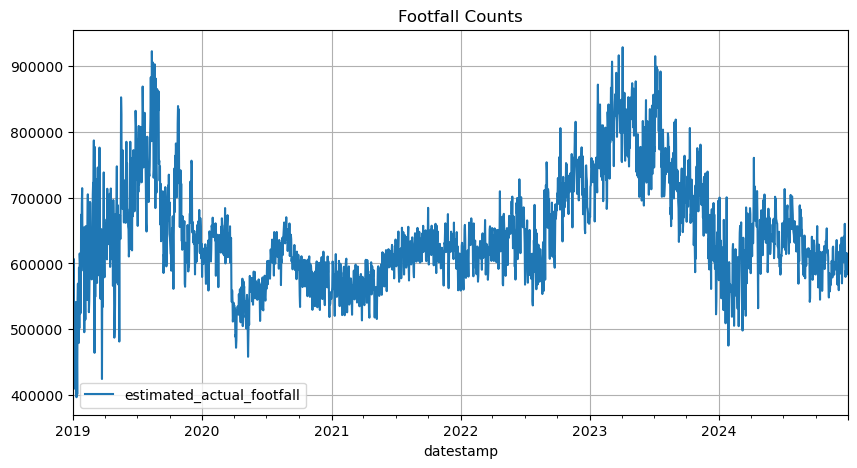

In [86]:
# Plot the entire time series and show gridlines
Y.plot(grid=True,figsize=(10,5), title = "Footfall Counts")
plt.show()

Data seems to show a non-linear trend, with no constant increase or decrease in trend. Let's decompose this time series in its components. Because the trend seems non-linear, the parameter `model` is set as multiplicative. Parameter `period` is set to the number of days in a year as the data is daily.

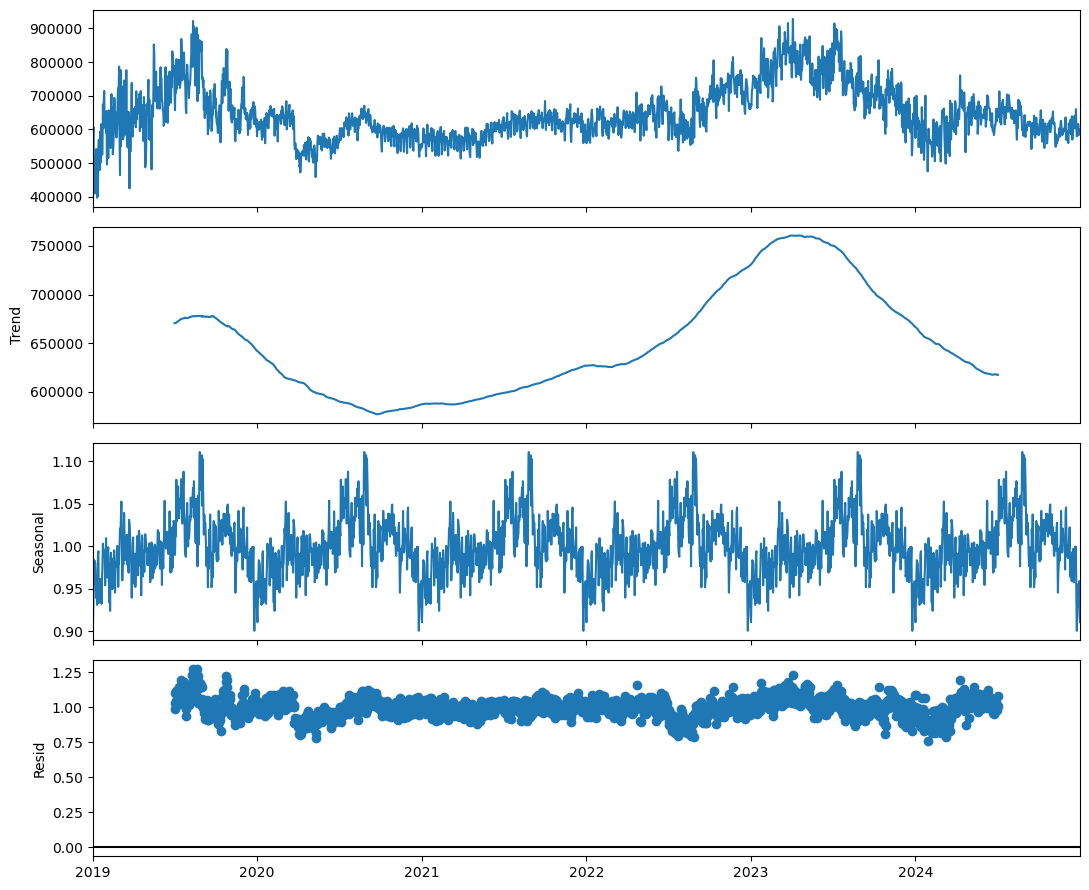

In [87]:
#Multiplicative model
from pylab import rcParams
rcParams['figure.figsize'] = 11, 9

import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(Y,
                                         model = 'multiplicative',
                                         period=365 #365 to 366 days in a year
                                         )
fig = decomposition.plot()
plt.show()

In [88]:
import scipy
print(scipy.__file__)

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\scipy\__init__.py


Both the frequency and the amplitude of the seasonal component don't seem to change with time, suggesting linear seasonality, i.e. a seasonal additive model, so the model is changed to additive:

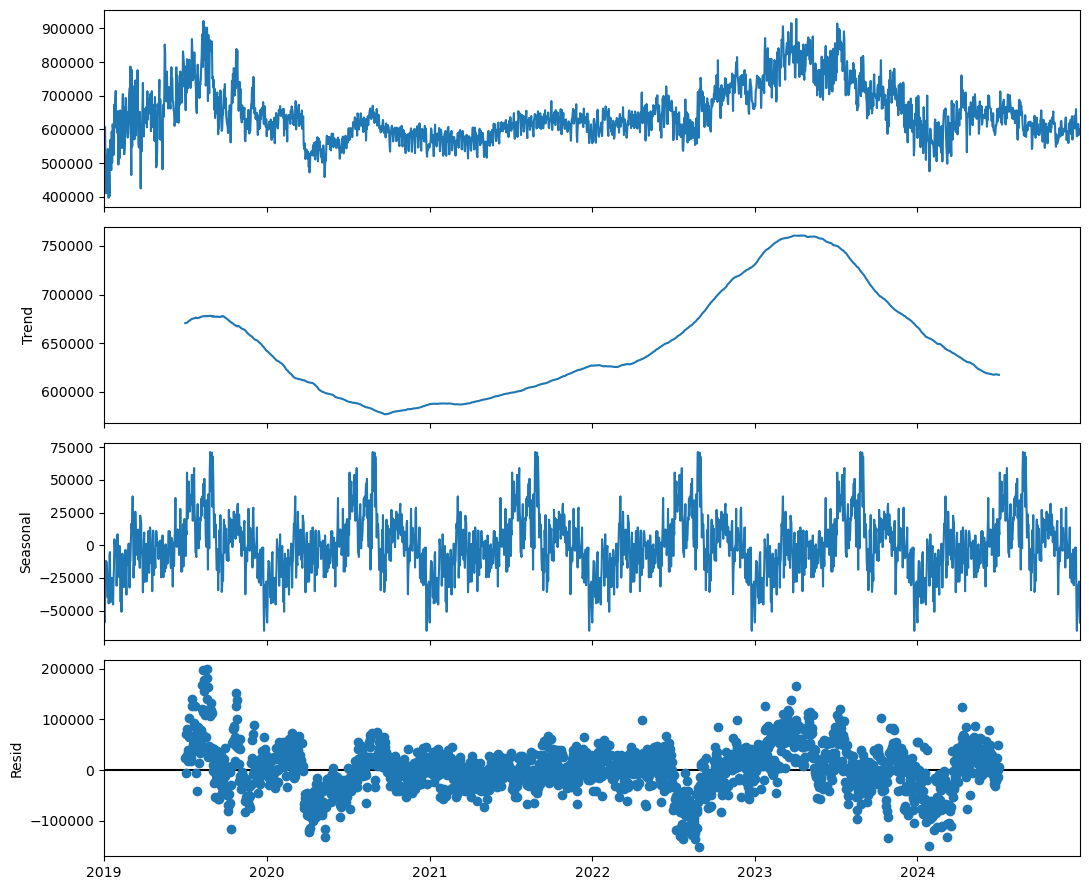

In [89]:
#Additive model
decomposition = sm.tsa.seasonal_decompose(Y,
                                         model = 'additive',
                                         period=365 #365 to 366 days in a year
                                         )
fig = decomposition.plot()
plt.show()

From these decompositions I can conclude that:
* The trend is non-linear, the time series follows no consistent upwards or downwards trend slope, suggesting non-stationarity. 
* From the seasonal component, it seems the amplitude and frequency of seasonality does not change, which suggests the model is additive. 
* The residuals are also much smaller in the additive model. So the additive model (Trend + Seasonality) fits the data more closely.
* Footfall counts seem higher during the summer months with a peak in July, and lowest during winter months, especially in December.

We check that the time series is indeed non-stationary with ADF and KPSS tests.

## Step 3: Stationarity Tests
**Augmented Dicky-Fuller test (ADF)** is a very popular test for stationarity. However, it can happen that a time series passes the ADF test, without being stationary. **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** is another test for checking the stationarity of a time series. It is prudent to apply both tests, so that it can be ensured that the series is truly stationary. Next to that, also observing the time series plot is important.

**ADF test**

ADF test is used to determine the presence of unit root in the series, and hence helps in understanding if the series is stationary or not. The null and alternate hypothesis of this test are:

Null Hypothesis: The series has a unit root, meaning it is non-stationary. It has some time dependent structure.

Alternate Hypothesis: The series has no unit root, meaning it is stationary. It does not have time-dependent structure.

If the null hypothesis failed to be rejected, this test may provide evidence that the series is non-stationary.

A p-value below a threshold (such as 5% or 1%) suggests we reject the null hypothesis (stationary), otherwise a p-value above the threshold suggests we fail to reject the null hypothesis (non-stationary).

**KPSS test**

The null and alternate hypothesis for the KPSS test is opposite that of the ADF test.

Null Hypothesis: The process is trend stationary.

Alternate Hypothesis: The series has a unit root (series is not stationary).

A p-value below a threshold (such as 5% or 1%) suggests we reject the null hypothesis (non-stationary), otherwise a p-value above the threshold suggests we fail to reject the null hypothesis (stationary).

In [90]:
#ADF TEST
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [91]:
#KPSS TEST
from statsmodels.tsa.stattools import kpss

def kpss_test(timeseries):
    print ('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c', nlags="auto")
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)


When applying those tests the following outcomes are possible:

**Case 1:** Both tests conclude that the series is not stationary - The series is not stationary

**Case 2:** Both tests conclude that the series is stationary - The series is stationary

**Case 3:** KPSS indicates stationarity and ADF indicates non-stationarity - The series is trend stationary. Trend needs to be removed to make series strict stationary. The detrended series is checked for stationarity.

**Case 4:** KPSS indicates non-stationarity and ADF indicates stationarity - The series is difference stationary. Differencing is to be used to make series stationary. The differenced series is checked for stationarity.

In [92]:
adf_test(Y)

Results of Dickey-Fuller Test:
Test Statistic                   -2.421437
p-value                           0.135777
#Lags Used                       26.000000
Number of Observations Used    2165.000000
Critical Value (1%)              -3.433374
Critical Value (5%)              -2.862876
Critical Value (10%)             -2.567481
dtype: float64


In [93]:
kpss_test(Y)

Results of KPSS Test:
Test Statistic            1.007635
p-value                   0.010000
Lags Used                28.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\2611369816.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression='c', nlags="auto")


**Results:** The ADF test shows a p-value > 5% suggesting the data is non-stationary. The KPSS test shows a p-value < 5% suggesting the data is non-stationary. Thus, both tests conclude the series is not stationary, and needs to be made stationary.

## Step 4: Making Time Series Stationary

The ARIMA models require the time series to be stationary to make effective and precise predictions. To make the time series stationary I use differencing: subtracting from each value in the time series the previous value.

I use the obtain_adf_kpss_results function to find out how many times I need to apply differencing in order to make this time series stationary. This will be the parameter d for the ARIMA model.

In [94]:
def obtain_adf_kpss_results(timeseries, max_d):
    """ Build dataframe with ADF statistics and p-value for time series after applying difference on time series
    
    Args:
        time_series (df): Dataframe of univariate time series  
        max_d (int): Max value of how many times apply difference
        
    Returns:
        Dataframe showing values of ADF statistics and p when applying ADF test after applying d times 
        differencing on a time-series.
    
    """
    
    results=[]

    for idx in range(max_d):
        adf_result = adfuller(timeseries, autolag='AIC')
        kpss_result = kpss(timeseries, regression='c', nlags="auto")
        timeseries = timeseries.diff().dropna()
        if adf_result[1] <=0.05:
            adf_stationary = True
        else:
            adf_stationary = False
        if kpss_result[1] <=0.05:
            kpss_stationary = False
        else:
            kpss_stationary = True
            
        stationary = adf_stationary & kpss_stationary
            
        results.append((idx,adf_result[1], kpss_result[1],adf_stationary,kpss_stationary, stationary))
    
    # Construct DataFrame 
    results_df = pd.DataFrame(results, columns=['d','adf_stats','p-value', 'is_adf_stationary','is_kpss_stationary','is_stationary' ])
    
    return results_df

In [95]:
obtain_adf_kpss_results(Y, 3)

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")


,d,adf_stats,p-value,is_adf_stationary,is_kpss_stationary,is_stationary
0,0,1.357772e-01,0.01,False,False,False
1,1,1.588793e-25,0.10,True,True,True
2,2,1.044466e-29,0.10,True,True,True


d=1, applying differencing only once is enough to make the time series stationary. The original time series and the time series after differencing once are plotted:

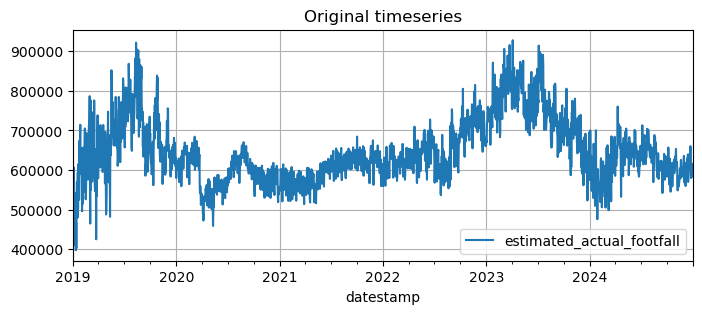

In [96]:
Y.plot(grid=True,figsize=(8,3), title = "Original timeseries" )
plt.show()

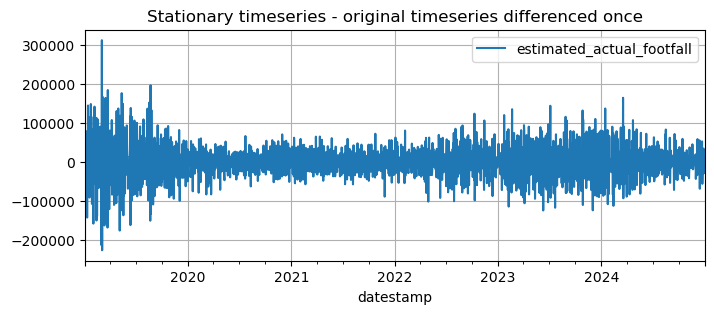

In [97]:
Y.diff().dropna().plot(grid=True,figsize=(8,3), title = "Stationary timeseries - original timeseries differenced once" )
plt.show()

The time series now looks stationary.

## Step 5: Plot ACF and PACF

Autocorrelation and Partial autocorrelation plots are heavily used in time series analysis and forecasting. They can give clues about promising values of ARIMA parameters. They also can shows us if we need to apply differencing of if we have applied it too much.

**AutoCorrelation Function** - ACF is the plot of the autocorrelation of a time series by lag. This plot is sometimes called a correlogram. It includes direct and indirect dependence information. In simple terms, ACF describes how well the present value of the series is related with its past values. The bars of the ACF plot represent the ACF values at increasing lags. The blue shaded area represents the confidence interval, which is set to 95% by default. If the bars lie inside the blue shaded region, then they are not statistically significant.

**Partial AutoCorrelation Function** - PACF only describes the direct relationship between an observation and its lag. Basically, instead of finding correlations of present with lags like ACF, it finds correlation of the residuals (which remains after removing the effects which are already explained by the earlier lag(s)).

**Finding p (AR term) and q (MA term):**


**ACF and PACF can also give tips about differencing.**

It is important to make time series stationary before making these plots. If the ACF values are high and trail off very slowly this is a sign that the data is non-stationarity, so it needs to be differenced.

If the autocorrelation at lag-1 is very negative this is a sign that we have taken the difference too many times.

We know that our time series is not stationary and need to be differenced. Let's plot ACF and PACF for the original and differenced time series.

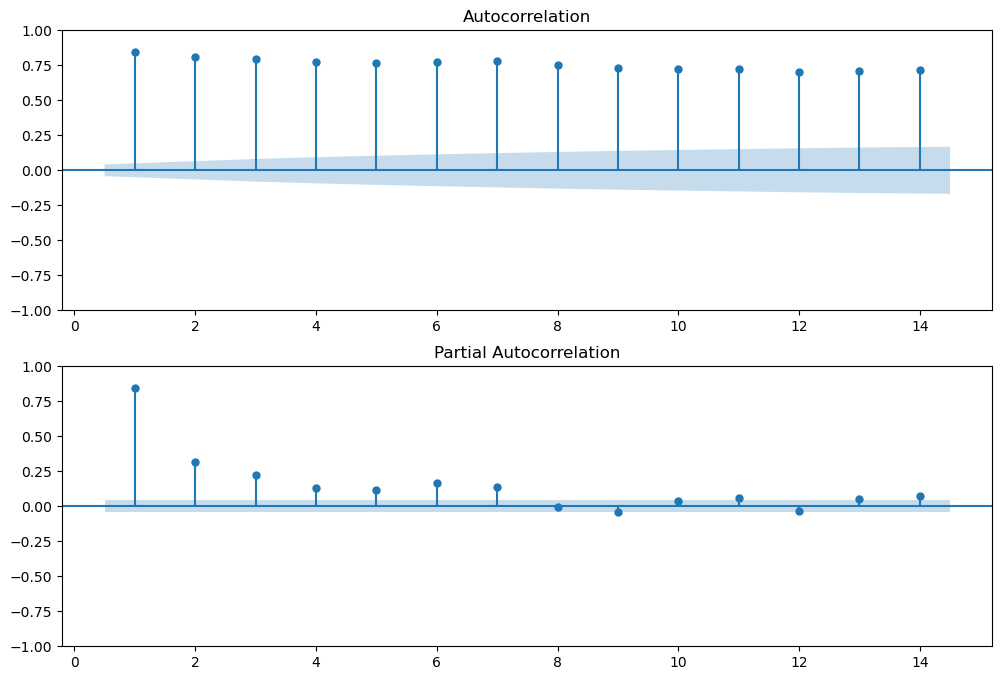

In [98]:
#Plot ACF and PACF with original time series

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
 
# Plot the ACF ax1
plot_acf(Y,lags=14, zero=False, ax=ax1)

# Plot the PACF ax2
plot_pacf(Y,lags=14, zero=False, ax=ax2)

plt.show()

The ACF seems to show a periodic correlation pattern. To find the period I need to look for a lag greater than one, which is a peak in the ACF plot. There seems to be a peak at 7, i.e. the seasonal component repeats every 7 steps thus a week.

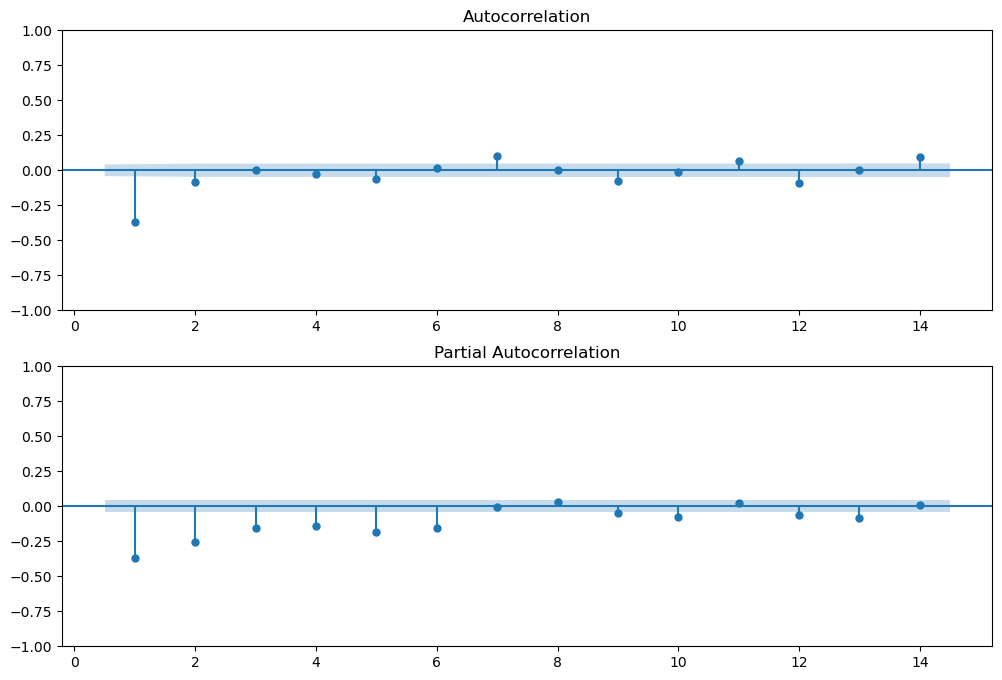

In [99]:
#Plot ACF and PACF with differenced time series

# Create figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
 
# Plot the ACF ax1
plot_acf(Y.diff().dropna(),lags=14, zero=False, ax=ax1)

# Plot the PACF ax2
plot_pacf(Y.diff().dropna(),lags=14, zero=False, ax=ax2)

plt.show()

By observing the ACF and PACF plots after making the time series stationary, we cannot see clear any trails off in neither of the plots.

We can also infer from those plots that there is a seasonal behavior of period 7 which is clear by the picks at lag 7 and 14 etc. (every week). This shows us the need of a seasonal term in my ARIMA model. So I need a SARIMA model.

In [100]:
# Take the first and seasonal differences (S=7) and drop NaNs
Y_diff = Y.diff().diff(7).dropna()

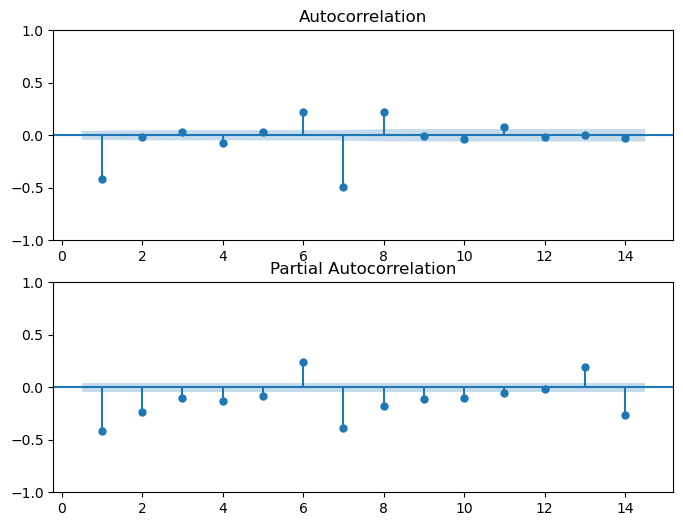

In [101]:
#Plot ACF and PACF with seasonal differenced time series (S=7)

# Create the figure 
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(8,6))

# Plot the ACF on ax1
plot_acf(Y_diff, lags=14, zero=False, ax=ax1)

# Plot the PACF on ax2
plot_pacf(Y_diff, lags=14, zero=False, ax=ax2)

plt.show()

The non-seasonal ACF and PACF plots show MA model pattern with q=1.
For the seasonal part, I set the lags parameter to a list of lags instead of a maximum, and then plot ACF and PACF for these specific lags only.

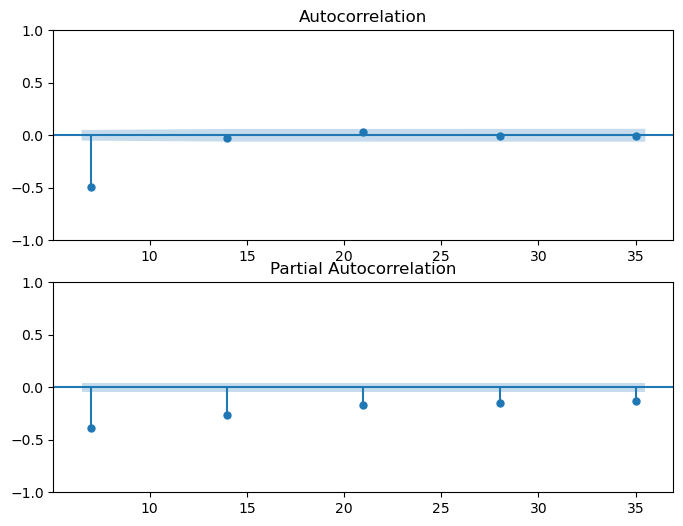

In [102]:
# Make list of lags
lags = [7, 14, 21, 28, 35]

# Create the figure 
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(8,6))

# Plot the ACF on ax1
plot_acf(Y_diff, lags=lags, zero=False, ax=ax1)

# Plot the PACF on ax2
plot_pacf(Y_diff, lags=lags, zero=False, ax=ax2)

plt.show()

The Seasonal ACF and PACF plots look like an MA(1) model, i.e., Q=1.

## Step 6: Estimate Coefficients (p, q)

Although I had clear signs that I need a SARIMA model, I will start by applying a ARIMA model instead. By doing so I can obtain a better understanding on the differences between ARIMA and SARIMA. In addition, it will be clear the advantages of choosing the appropriate model.

ACF and PACF plots can help to find appropriate values for parameters p and q . However, the interpretation of these plots is not always clear. To obtain more assurance to my choices I can apply an empirical method. This method consists on fitting the ARIMA model for different values of p and q, and choosing the best value based on metrics such as AIC and BIC.

**AIC (Akaike information criterion)** is a metric which tells us how good a model is. Lower the value, better the model. The AIC also penalizes models which have lots of parameters. This means if we set the order too high compared to the data, we will get a high AIC value. This stops us overfitting to the training data.

**BIC (Bayesian information criterion)** is similar to AIC, therefore lower value means a better model. However, BIC penalizes additional model orders more than AIC. As consequence, BIC will sometimes suggest a simpler model.

After fitting a model, I can access its summary statistics, and there is where I can find the values of AIC and BIC.

Usually there is agreement between AIC and BIC. If there is no agreement choose smaller AIC if prefer a predictive model. Otherwise, choose smaller BIC for an explanatory model.

In [103]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#Fit an ARIMA model as example (using SARIMAX class)
model = SARIMAX(Y, order=(1,1,1), freq='D')
results = model.fit()
# statistics of the model
results.summary()

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                   SARIMAX Results                                   
=====================================================================================
Dep. Variable:     estimated_actual_footfall   No. Observations:                 2192
Model:                      SARIMAX(1, 1, 1)   Log Likelihood              -26235.991
Date:                       Tue, 13 Jan 2026   AIC                          52477.982
Time:                               14:44:14   BIC                          52495.058
Sample:                           01-01-2019   HQIC                         52484.223
                                - 12-31-2024                                         
Covariance Type:                         opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2799      0.017     16.603      0.000       0.247       0.313
ma.L1         -0.8332      0.013    -66.548      0.000      -0.858      -0.809
sigma2       1.54e+09   7.53e-13   2.05e+21      0.000    1.54e+09    1.54e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.43   Jarque-Bera (JB):               520.01
Prob(Q):                              0.51   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.33e+36. Standard errors may be unstable.
"""

Now I scan different values of p and q and choose the values that points to smaller AIC and/or BIC.

In [104]:
# Create empty list to store search results
order_aic_bic=[]

# Loop over p values from 0-6
for p in range(7):
  # Loop over q values from 0-6
    for q in range(7):
      	# create and fit ARMA(p,q) model
        model = SARIMAX(Y, order=(p,1,q), freq="D") #because adf test showed that d=1
        results = model.fit()
        
        # Append order and results tuple
        order_aic_bic.append((p,q,results.aic, results.bic))

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473

In [105]:
# Construct DataFrame from order_aic_bic
order_df = pd.DataFrame(order_aic_bic, 
                        columns=['p','q','AIC','BIC'])

# Print order_df in order of increasing AIC
order_df.sort_values('AIC')

,p,q,AIC,BIC
48,6,6,52340.933055,52414.930528
41,5,6,52358.594464,52426.899824
34,4,6,52371.887201,52434.500448
45,6,3,52384.696884,52441.618017
39,5,4,52401.774214,52458.695348
26,3,5,52409.808063,52461.037084
33,4,5,52439.339729,52496.260862
25,3,4,52440.201347,52485.738253
17,2,3,52446.311025,52480.463705
31,4,3,52451.254101,52496.791008


In [106]:
# Print order_df in order of increasing BIC
order_df.sort_values('BIC')

,p,q,AIC,BIC
48,6,6,52340.933055,52414.930528
41,5,6,52358.594464,52426.899824
34,4,6,52371.887201,52434.500448
45,6,3,52384.696884,52441.618017
39,5,4,52401.774214,52458.695348
26,3,5,52409.808063,52461.037084
17,2,3,52446.311025,52480.463705
25,3,4,52440.201347,52485.738253
18,2,4,52452.687137,52492.531931
8,1,1,52477.981808,52495.058148


**Results:** Both AIC and BIC agree that the best model in this case should be (6, 1, 6).

## Step 7: ARIMA Model Evaluation

ARIMA uses three parameters - ARIMA(p,d,q):

* Auto Regressive term p: Number of autoregressive lags
* Order of differencing term d: Number of times differencing pre-processing step is applied to make the time series stationary
* Moving Average term q: Number of moving average lags


Before, using a model we want to know how accurate it is. Here we use evaluation metrics to evaluate the model before considering it the best one and putting it to production.

For this evaluation I focus on the residuals. The residuals are the difference between the model's one-step-ahead predictions and the real values of the time series.

In [107]:
#  Mean Absolute Error (MAE) of the residuals
# This will show how far, on average, the predictions 
# are from the true values.

arima_model = SARIMAX(Y, order=(6,1,6))
# fit model
arima_results = arima_model.fit()

# Calculate the mean absolute error from residuals
mae = np.mean(np.abs(arima_results.resid))

# Print mean absolute error
print('MAE: %.3f' % mae)

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 26937.793


c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [108]:
Y.describe()

,estimated_actual_footfall
count,2192.000000
mean,646736.310675
std,80221.589961
min,397085.000000
25%,593639.000000
50%,629997.000000
75%,688500.500000
max,928063.000000


The mean average error is about 26879 people per day whereas the average footfall count is 646,736. Can the model be improved?
For an ideal model, the residuals should be uncorrelated white Gaussian noise centered on zero. Therefore, continuing my model evaluation I use tools that allow us to check if it is true.

### Diagnostic Summary Statistics
Another important tool to evaluate the model is the analysis of the residual test statistics in the results summary.

Now I evaluate Prob(Q) and Prob(JB) applying, respectively, the following tests:

**Ljung–Box test:**

Null hypothesis: There are no correlations in the residuals.

**Jarque–Bera test**

Null hypothesis: Residuals are normally distributed.

In [109]:
arima_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   SARIMAX Results                                   
=====================================================================================
Dep. Variable:     estimated_actual_footfall   No. Observations:                 2192
Model:                      SARIMAX(6, 1, 6)   Log Likelihood              -26157.467
Date:                       Tue, 13 Jan 2026   AIC                          52340.933
Time:                               14:45:43   BIC                          52414.931
Sample:                           01-01-2019   HQIC                         52367.978
                                - 12-31-2024                                         
Covariance Type:                         opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0417      0.028      1.495      0.135      -0.013       0.096
ar.L2         -0.5962      0.020    -29.355      0.000      -0.636      -0.556
ar.L3         -0.4512      0.026    -17.484      0.000      -0.502      -0.401
ar.L4         -0.0241      0.024     -1.008      0.314      -0.071       0.023
ar.L5         -0.9119      0.019    -47.989      0.000      -0.949      -0.875
ar.L6          0.2425      0.023     10.453      0.000       0.197       0.288
ma.L1         -0.5720      0.026    -22.272      0.000      -0.622      -0.522
ma.L2          0.4565      0.024     19.045      0.000       0.409       0.503
ma.L3          0.0849      0.026      3.292      0.001       0.034       0.135
ma.L4         -0.3469      0.025    -14.058      0.000      -0.395      -0.299
ma.L5          0.7942      0.024     32.836      0.000       0.747       0.842
ma.L6         -0.7528      0.024    -31.267      0.000      -0.800      -0.706
sigma2      1.376e+09   1.01e-11   1.36e+20      0.000    1.38e+09    1.38e+09
===================================================================================
Ljung-Box (L1) (Q):                   4.04   Jarque-Bera (JB):               723.47
Prob(Q):                              0.04   Prob(JB):                         0.00
Heteroskedasticity (H):               0.68   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.35e+36. Standard errors may be unstable.
"""

**Results:**

Prob(Q) = 0.1 > 0.05. I shouldn't reject the null hypothesis that the residuals are uncorrelated so the residuals are not correlated.

Prob(JB) = 0.00 < 0.05. We reject the null hypothesis that the residuals are normally distributed. Therefore, the residuals are not normally distributed.

### Plot Diagnostics

In addition, there are 4 common plots to help decide whether a model is a good fit for the data in question.

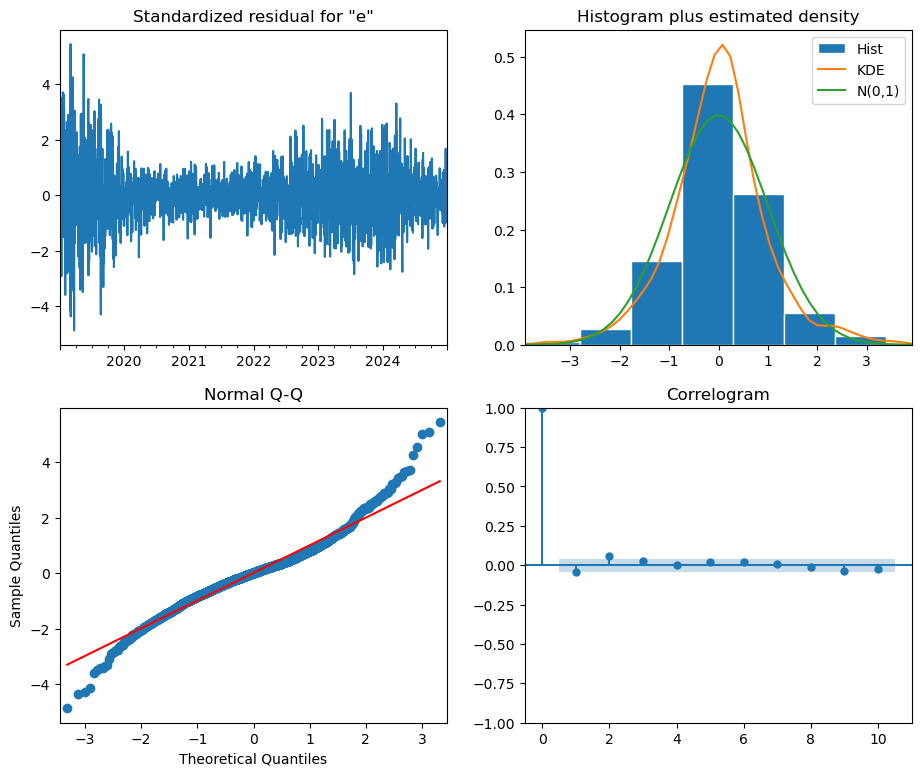

In [110]:
# Create the 4 diagostics plots using plot_diagnostics method
arima_results.plot_diagnostics()
plt.show()

For an ideal model the residuals should be uncorrelated white Gaussian noise centered on zero. By analyzing the plots above having this in mind I can evaluate if I have a good model or not.

So, let's analyze those plots (Clockwise from left-top plot):

* **Standardized residual:** There are some patterns in the residuals. This points out to a not good model.

* **Histogram plus kde estimate:** The histogram shows the measured distribution of the residuals while the green line shows the KDE curve (smoothed version of the histogram). The green line shows a normal distribution. For a good model the orange line should be similar to the green line. The orange curve is not very similar to the green one.

* **Correlogram or ACF plot:** 95% of correlations for lag greater than one should not be significant (inside the blue area). This is also the case, i.e., good model.

* **Normal Q-Q:** Most of the data points should lie on the straight line, indicating a normal distribution of the residuals. This somewhat happens here, but quantiles drift off at the tips.

Therefore, all in all the model pointed by our empirical search seems to not be a good model.


**Final tips:**

If the residuals are not normally distributed, need to try to increase d.

If the residuals are correlated need to try to increase p or q.

## Step 8: SARIMA model

I know consider seasonality. For this I need to choose also the seasonal parameters P, Q, D and S.

Therefore, the ACF plot can help in finding out the time period, especially if it is not clear from the plots of the time series.

**Important:** Make time series is stationary first.

### Seasonal differencing 

In order to make a time series stationary we may use differencing and that's how I determine the parameter d of ARIMA, together with ADF test.

For a seasonal time series, I may need to apply seasonal differencing. In seasonal differencing, instead of subtracting the most recent time series value, I subtract the time series value from one cycle ago. Therefore, if the time series shows a trend, then I take the normal difference. If there is a strong seasonal cycle, then I will also take the seasonal difference.

Furthermore, in the case of strong seasonality, as observed in our time series, D=1. A rule of thumb is that d + D should not be greater than 2.

Once I have found the two orders of differencing, d and D, and made the time series stationary, I need to find the other model orders.

As before, to find non-seasonal orders, p and q, a plot ACF and PACF of differenced time series can be used. However, to find seasonal orders P and Q I need to plot ACF and PACF of the differenced time series at multiple seasonal steps.

**Results:** As seen previously, the Seasonal ACF and PACF plots look like an MA(1) model, i.e., Q=1. We could select the model that combines both of these, i.e., SARIMA(6, 1, 6)(0, 1, 1)7.

* p = 6 -> was determined by AIC and BIC metrics
* d = 1 -> was determined by adf and kpss tests
* q = 6 -> was determined by AIC and BIC metrics

* P = 1 -> was determined by seasonal PACF plot (sharp cutoff at lag 7 means P=1, otherwise if no seasonal PACF spike P=0)
* D = 0 -> was determined by seasonal ACF and ADF/KPSS on y.diff(7),D=1 if seasonality remains after non-seasonal differencing
* Q = 1 -> was determined by seasonal ACF plot (ACF spike at lag S means Q=1, if ACF spikes at lags S and 2S means Q=2)
* S = 7 -> was determined by the ACF and PACF plots showing weekly seasonality


In [111]:
obtain_adf_kpss_results(Y_diff, 3)

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")


,d,adf_stats,p-value,is_adf_stationary,is_kpss_stationary,is_stationary
0,0,2.059238e-26,0.1,True,True,True
1,1,0.000000e+00,0.1,True,True,True
2,2,0.000000e+00,0.1,True,True,True


So D = 0.

### Fitting and evaluating SARIMA model

In [112]:
sarima_01_model = SARIMAX(Y, order=(6,1,6), seasonal_order=(1,0,1,7))
sarima_01_results = sarima_01_model.fit()

# Calculate the mean absolute error from residuals
mae = np.mean(np.abs(sarima_01_results.resid))

# Print mean absolute error
print('MAE: %.3f' % mae)

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 27176.641


The MAE is a bit higher than in the ARIMA model.

In [113]:
sarima_01_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:           estimated_actual_footfall   No. Observations:                 2192
Model:             SARIMAX(6, 1, 6)x(1, 0, [1], 7)   Log Likelihood              -26166.701
Date:                             Tue, 13 Jan 2026   AIC                          52363.402
Time:                                     14:45:55   BIC                          52448.784
Sample:                                 01-01-2019   HQIC                         52394.608
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0458      0.045     -1.014      0.311      -0.134       0.043
ar.L2         -0.6057      0.030    -20.313      0.000      -0.664      -0.547
ar.L3         -0.4653      0.032    -14.745      0.000      -0.527      -0.403
ar.L4         -0.0433      0.030     -1.466      0.143      -0.101       0.015
ar.L5         -0.8800      0.025    -35.558      0.000      -0.929      -0.832
ar.L6          0.1684      0.031      5.446      0.000       0.108       0.229
ma.L1         -0.5045      0.045    -11.171      0.000      -0.593      -0.416
ma.L2          0.4324      0.029     15.041      0.000       0.376       0.489
ma.L3          0.0896      0.022      4.006      0.000       0.046       0.133
ma.L4         -0.3400      0.019    -17.640      0.000      -0.378      -0.302
ma.L5          0.7728      0.030     25.932      0.000       0.714       0.831
ma.L6         -0.6732      0.040    -16.720      0.000      -0.752      -0.594
ar.S.L7        0.3906     20.772      0.019      0.985     -40.322      41.103
ma.S.L7       -0.3900     20.774     -0.019      0.985     -41.107      40.327
sigma2      1.376e+09   2.11e-06   6.51e+14      0.000    1.38e+09    1.38e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.66   Jarque-Bera (JB):               722.42
Prob(Q):                              0.42   Prob(JB):                         0.00
Heteroskedasticity (H):               0.68   Skew:                             0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.37e+30. Standard errors may be unstable.
"""

**Results:**
* Prob(Q) = 0.33 > 0.05. I shouldn't reject the null hypothesis that the residuals are uncorrelated so the residuals are not correlated.

* Prob(JB) = 0.00 < 0.05. I should reject the null hypothesis that the residuals are normally distributed. Therefore, the residuals are not normally distributed.

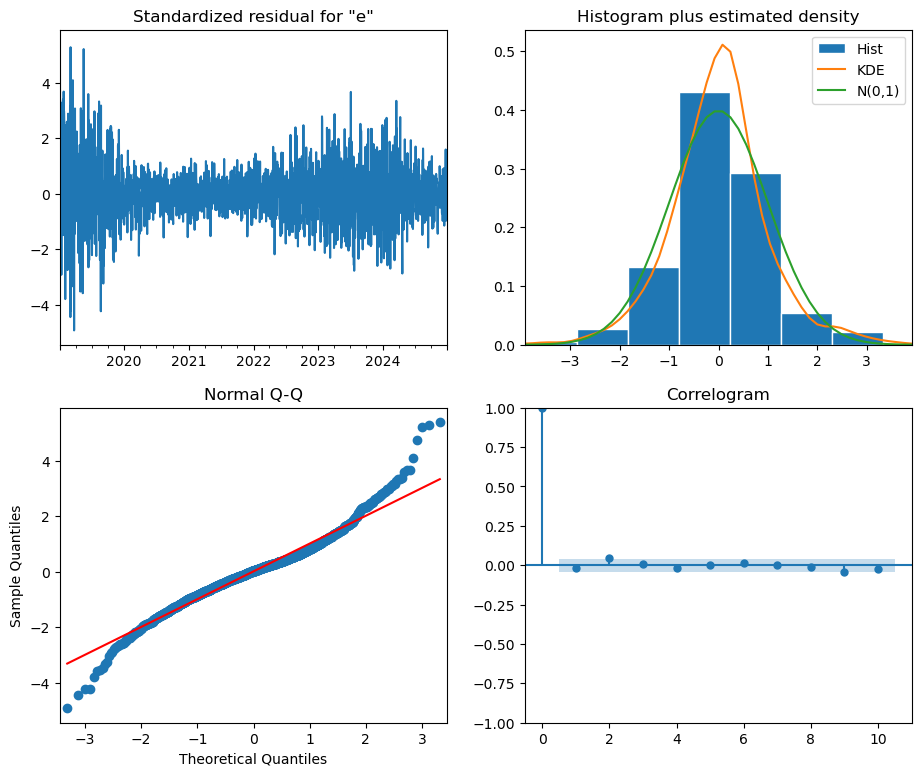

In [114]:
sarima_01_results.plot_diagnostics()
plt.show()

* **Standardized residual:** There are some patterns in the residuals. This points out to a not good model.

* **Histogram plus kde estimate:** The histogram shows the measured distribution of the residuals while the green line shows the KDE curve (smoothed version of the histogram). The green line shows a normal distribution. For a good model the orange line should be similar to the green line. The orange curve is not very similar to the green one.

* **Correlogram or ACF plot:** 95% of correlations for lag greater than one should not be significant (inside the blue area). This is also the case, i.e., good model.

* **Normal Q-Q:** Most of the data points should lie on the straight line, indicating a normal distribution of the residuals. This somewhat happens here, but quantiles drift off at the tips.

Therefore, all in all the model pointed by our empirical search seems to not be a good model.

## Step 9: Automated Model Selection

Another way to determine model parameters is the empiric method considering values of AIC and BIC. However, now we have much more parameters to consider. In this case, the use of Automated Model Selection might be very handy.

**pmdarima** allows us to automate the search of model orders. I use information I got from the Box-Jenkins identification step to predefine some of the orders before I fit. Automated Model Selection can speed up the process of choosing model orders, but needs to be done with care. Automation can make mistakes since the input data can be imperfect and affect the test scores in non-predictable ways.

The only non-optional parameter in **auto_arima** is data. However, using my knowledge to specify other parameters can help finding the best model.

In [115]:
Y.head()

,estimated_actual_footfall
datestamp,
2019-01-01,530996.0
2019-01-02,568621.0
2019-01-03,606939.0
2019-01-04,508695.0
2019-01-05,468546.0


In [116]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [117]:
#import pmdarima as pm

# Create auto_arima model
#model1 = pm.auto_arima(Y, #time series
                      #seasonal=True, # is the time series seasonal
                      #m=7, # the seasonal period - one week?
                      #d=1, # non-seasonal difference order
                      #D=0, # seasonal difference order
                 	  #max_p=6, # max value of p to test 
                      #max_q=6, # max value of p to test
                      #max_P=6, # max value of P to test 
                      #max_Q=6, # max value of Q to test 
                      #information_criterion='aic', # used to select best mode
                      #trace=True, # prints the information_criterion for each model it fits
                      #error_action='ignore', # ignore orders that don't work
                      #stepwise=True, # apply an intelligent order search
                      #suppress_warnings=True) 

# Print model summary
#print(model1.summary())

**Results:** 
* The Automated model selection choses SARIMA(3,1,3)(1,0,1)7 as the best model based on AIC when d=1 and D=0.

I re-fit the model based on these parameters:

In [118]:
sarima_02_model = SARIMAX(Y, order=(3,1,3), seasonal_order=(1,0,1,7))
sarima_02_results = sarima_02_model.fit()

# Calculate the mean absolute error from residuals
mae = np.mean(np.abs(sarima_02_results.resid))

# Print mean absolute error
print('MAE: %.3f' % mae)

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 26616.105


This value is a bit lower than the one obtained by previous SARIMA model, reducing prediction error and making it a better model.

In [119]:
sarima_02_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:           estimated_actual_footfall   No. Observations:                 2192
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood              -26138.461
Date:                             Tue, 13 Jan 2026   AIC                          52294.923
Time:                                     14:46:05   BIC                          52346.152
Sample:                                 01-01-2019   HQIC                         52313.646
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.1445      0.021    103.671      0.000       2.104       2.185
ar.L2         -1.3764      0.011   -127.304      0.000      -1.398      -1.355
ar.L3          0.2181      0.007     31.683      0.000       0.205       0.232
ma.L1         -2.7016      0.025   -106.031      0.000      -2.752      -2.652
ma.L2          2.4391      0.040     60.700      0.000       2.360       2.518
ma.L3         -0.7345      0.017    -43.381      0.000      -0.768      -0.701
ar.S.L7        0.9990      0.001    835.627      0.000       0.997       1.001
ma.S.L7       -0.9902      0.006   -156.618      0.000      -1.003      -0.978
sigma2      1.421e+09   3.37e-12   4.21e+20      0.000    1.42e+09    1.42e+09
===================================================================================
Ljung-Box (L1) (Q):                   1.47   Jarque-Bera (JB):               848.98
Prob(Q):                              0.23   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.5e+36. Standard errors may be unstable.
"""

Prob(Q) 0.44 > 0.05. I shouldn't reject the null hypothesis that the residuals are uncorrelated so the residuals are not correlated.

Prob(JB) 0.00 < 0.05. I should reject the null hypothesis that the residuals are normally distributed. Therefore, the residuals are not normally distributed.

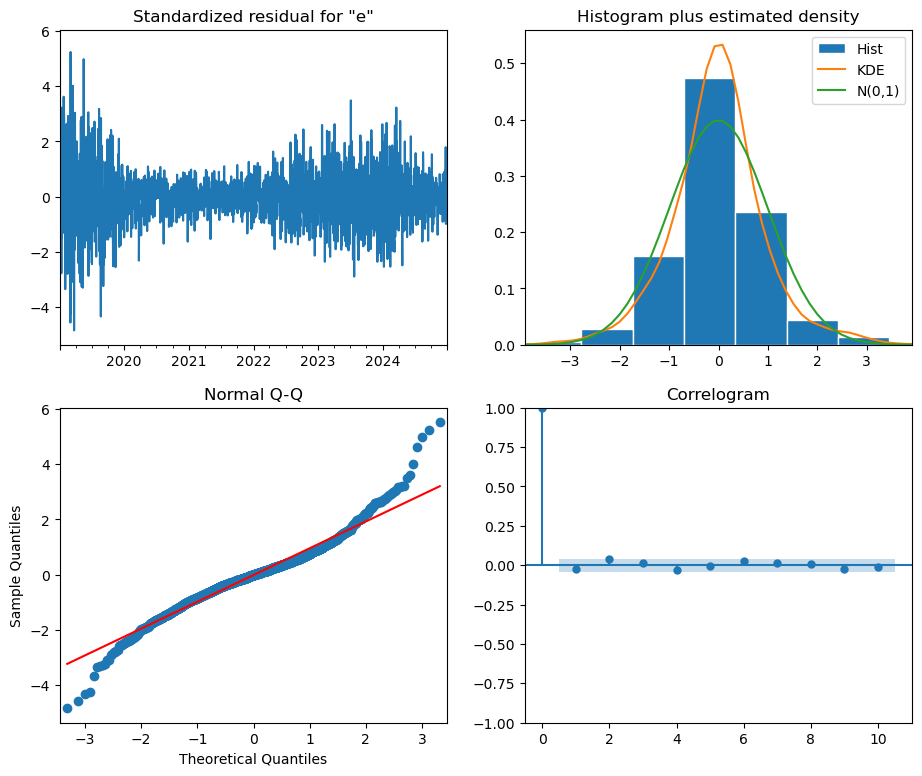

In [120]:
# Create the 4 diagnostics plots
sarima_02_results.plot_diagnostics()
plt.show()

## Step 10: SARIMA - wit Log Data Transformation

Even after searching for the best model parameters to fit the data, the residuals are still not normally distributed. I decide to try transforming the data.

In [121]:
#Transform to the footfall counts to log scale
# +1 to if zeros exist
Y_log = np.log(Y + 1)
#check
Y_log

,estimated_actual_footfall
datestamp,
2019-01-01,13.182512
2019-01-02,13.250971
2019-01-03,13.316185
2019-01-04,13.139606
2019-01-05,13.057392
...,...
2024-12-27,13.330898
2024-12-28,13.281191
2024-12-29,13.277980


In [122]:
#Get d parameter on log transformed data
obtain_adf_kpss_results(Y_log, 3)

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")


,d,adf_stats,p-value,is_adf_stationary,is_kpss_stationary,is_stationary
0,0,1.319173e-01,0.01,False,False,False
1,1,4.981071e-26,0.10,True,True,True
2,2,8.155576e-30,0.10,True,True,True


So d still needs to be equal to 1.

In [123]:
# Take the first and seasonal differences (S=7) and drop NaNs
Y_log_diff = Y_log.diff().diff(7).dropna()

#Get D parameter on differenced log transformed data 
obtain_adf_kpss_results(Y_log, 3)

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")


,d,adf_stats,p-value,is_adf_stationary,is_kpss_stationary,is_stationary
0,0,1.319173e-01,0.01,False,False,False
1,1,4.981071e-26,0.10,True,True,True
2,2,8.155576e-30,0.10,True,True,True


So with log transformed footfall data, the parameter D should be 1 (not 0 like in the non-transformed data). I run the automated model selection search again with the log transformed data, with d=1 and D=1.

In [124]:
#import pmdarima as pm

# Create auto_arima model
#model2 = pm.auto_arima(Y_log, #time series
                      #seasonal=True, # is the time series seasonal
                      #m=7, # the seasonal period - one week?
                      #d=1, # non-seasonal difference order
                      #D=1, # seasonal difference order
                 	  #max_p=6, # max value of p to test 
                      #max_q=6, # max value of p to test
                      #max_P=6, # max value of P to test 
                      #max_Q=6, # max value of Q to test 
                      #information_criterion='aic', # used to select best mode
                      #trace=True, # prints the information_criterion for each model it fits
                      #error_action='ignore', # ignore orders that don't work
                      #stepwise=True, # apply an intelligent order search
                      #suppress_warnings=True) 

# Print model summary
#print(model2.summary())

**Results:**
* Best model:  SARIMA(5,1,1)(6,1,1)[7] comes out for d=1 and D=1, with log transformed Y.

In [125]:
sarima_03_model = SARIMAX(Y_log, order=(5,1,1), 
                          seasonal_order=(6,1,1,7), 
                          freq='D')
sarima_03_results = sarima_03_model.fit()

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [126]:
sarima_03_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:         estimated_actual_footfall   No. Observations:                 2192
Model:             SARIMAX(5, 1, 1)x(6, 1, 1, 7)   Log Likelihood                3153.443
Date:                           Tue, 13 Jan 2026   AIC                          -6278.887
Time:                                   14:46:32   BIC                          -6199.242
Sample:                               01-01-2019   HQIC                         -6249.773
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0822      0.082      0.998      0.318      -0.079       0.244
ar.L2         -0.0101      0.046     -0.217      0.828      -0.101       0.081
ar.L3         -0.0135      0.033     -0.414      0.679      -0.077       0.050
ar.L4         -0.0799      0.026     -3.063      0.002      -0.131      -0.029
ar.L5         -0.0172      0.025     -0.676      0.499      -0.067       0.033
ma.L1         -0.6479      0.084     -7.745      0.000      -0.812      -0.484
ar.S.L7       -0.1249      0.032     -3.899      0.000      -0.188      -0.062
ar.S.L14      -0.1606      0.028     -5.795      0.000      -0.215      -0.106
ar.S.L21      -0.0896      0.025     -3.568      0.000      -0.139      -0.040
ar.S.L28      -0.0766      0.024     -3.249      0.001      -0.123      -0.030
ar.S.L35      -0.0754      0.022     -3.481      0.000      -0.118      -0.033
ar.S.L42      -0.0426      0.018     -2.410      0.016      -0.077      -0.008
ma.S.L7       -0.7906      0.029    -27.306      0.000      -0.847      -0.734
sigma2         0.0033   6.65e-05     49.173      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                   1.30   Jarque-Bera (JB):               986.81
Prob(Q):                              0.25   Prob(JB):                         0.00
Heteroskedasticity (H):               0.64   Skew:                            -0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

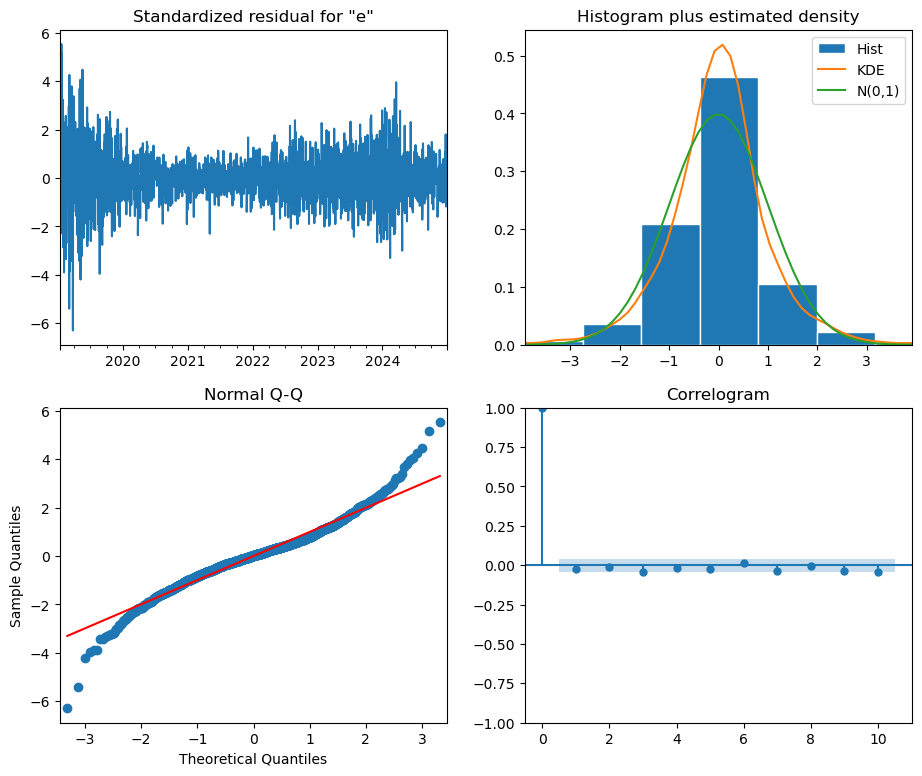

In [127]:
# Create the 4 diagnostics plots
sarima_03_results.plot_diagnostics()
plt.show()

## Step 11: SARIMAX

ARIMA:
* AR (AutoRegressive) = p
* I (Integrated) = d
* MA (Moving Average) = q


Out of the different possible ARIMA models, I choose to use a SARIMAX model as:
1) S = I want to include seasonality for better predictions
2) X = I want to include exogenous inputs, i.e. other independent variables, such as weather predictors.

Therefore, a SARIMA(p,d,q)(P,D,Q,S) model will have non-seasonal parameters (p,d,q) and P,D,Q,S that are the seasonal parameters, i.e.,

**Non-seasonal orders**

* p: Autoregressive order
* d: Differencing order
* q: Moving average order

**Seasonal orders**

* P: Seasonal autoregressive order
* D: Seasonal differencing order
* Q: Seasonal moving average order
* S: Length of the seasonal cycle


Both the ARIMA and SARIMA models had residuals which were not normally distributed. I try testing if the SARIMAX model, which will allow to incorporate eXogenous predictors, will better fit the data.

### SARIMAX with Manually selected parameters

In [128]:
sarimax_01_model = SARIMAX(endog= Y,
                        exog= X,
                        order=(6,1,6), 
                        seasonal_order=(1,0,1,7),
                        freq="D")
sarimax_01_results = sarimax_01_model.fit()

# Calculate the mean absolute error from residuals
mae = np.mean(np.abs(sarimax_01_results.resid))

# Print mean absolute error
print('MAE: %.3f' % mae)

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 27192.204


In [129]:
sarimax_01_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:           estimated_actual_footfall   No. Observations:                 2192
Model:             SARIMAX(6, 1, 6)x(1, 0, [1], 7)   Log Likelihood              -26162.680
Date:                             Tue, 13 Jan 2026   AIC                          52369.360
Time:                                     14:46:48   BIC                          52494.586
Sample:                                 01-01-2019   HQIC                         52415.128
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
bank_hol            -1.223e+04   4915.355     -2.489      0.013   -2.19e+04   -2598.037
school_hol           1.896e+04   3676.862      5.157      0.000    1.18e+04    2.62e+04
covid               -1907.3888      7.962   -239.552      0.000   -1922.995   -1891.783
temperature_2m_mean   125.9400    425.277      0.296      0.767    -707.587     959.467
precipitation_sum    -202.9880    163.045     -1.245      0.213    -522.550     116.574
wind_speed_10m_max   -235.1953    111.496     -2.109      0.035    -453.723     -16.667
daylight_duration       1.5029      0.723      2.078      0.038       0.085       2.921
ar.L1                  -0.0870      0.043     -2.041      0.041      -0.171      -0.003
ar.L2                  -0.6178      0.026    -23.770      0.000      -0.669      -0.567
ar.L3                  -0.5053      0.029    -17.202      0.000      -0.563      -0.448
ar.L4                  -0.0842      0.027     -3.092      0.002      -0.138      -0.031
ar.L5                  -0.9047      0.021    -42.484      0.000      -0.946      -0.863
ar.L6                   0.1205      0.029      4.091      0.000       0.063       0.178
ma.L1                  -0.4536      0.043    -10.576      0.000      -0.538      -0.370
ma.L2                   0.4568      0.024     18.705      0.000       0.409       0.505
ma.L3                   0.1481      0.019      7.666      0.000       0.110       0.186
ma.L4                  -0.2927      0.017    -17.259      0.000      -0.326      -0.259
ma.L5                   0.8100      0.024     33.276      0.000       0.762       0.858
ma.L6                  -0.6280      0.037    -16.910      0.000      -0.701      -0.555
ar.S.L7                 0.3160      7.282      0.043      0.965     -13.955      14.587
ma.S.L7                -0.3180      7.281     -0.044      0.965     -14.589      13.953
sigma2               1.375e+09      0.019   7.28e+10      0.000    1.37e+09    1.37e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.83   Jarque-Bera (JB):               623.34
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               0.71   Skew:                             0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 7.73e+25. Standard errors may be unstable.
"""

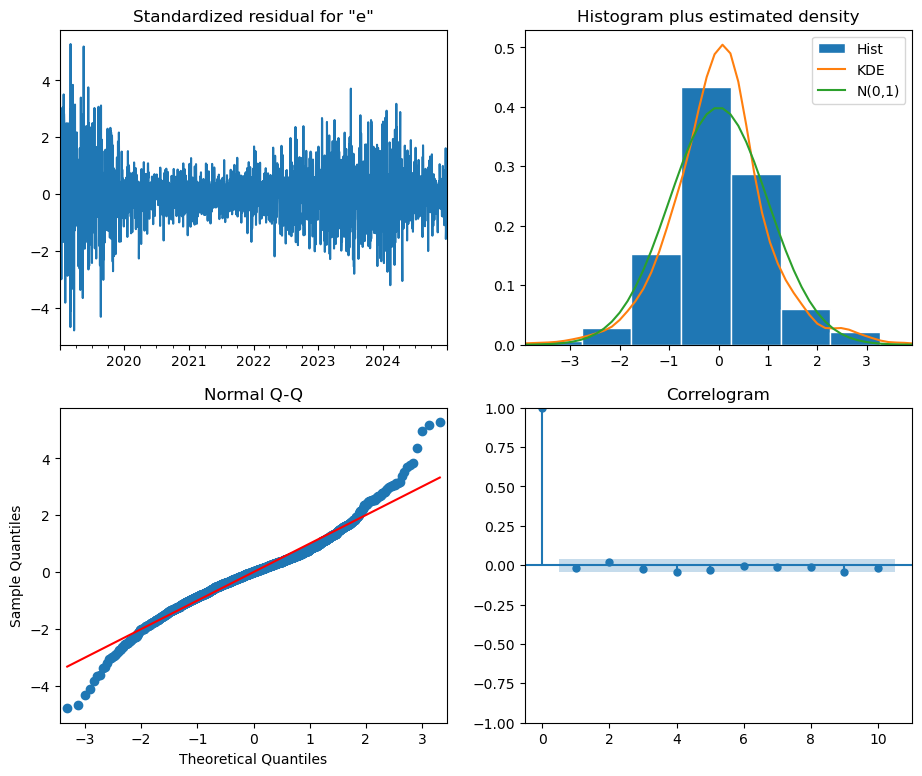

In [130]:
# Create the 4 diagnostics plots
sarimax_01_results.plot_diagnostics()
plt.show()

### SARIMAX with Automatically selected parameters

In [131]:
sarimax_02_model = SARIMAX(endog= Y,
                        exog= X,
                        order=(3,1,3), 
                        seasonal_order=(1,0,1,7),
                        freq="D")
sarimax_02_results = sarimax_02_model.fit()

# Calculate the mean absolute error from residuals
mae = np.mean(np.abs(sarimax_02_results.resid))

# Print mean absolute error
print('MAE: %.3f' % mae)

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 26684.389


In [132]:
sarimax_02_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:           estimated_actual_footfall   No. Observations:                 2192
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood              -26132.575
Date:                             Tue, 13 Jan 2026   AIC                          52297.149
Time:                                     14:46:58   BIC                          52388.223
Sample:                                 01-01-2019   HQIC                         52330.435
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
bank_hol            -1.223e+04   4803.689     -2.546      0.011   -2.16e+04   -2816.902
school_hol           1.896e+04   3815.804      4.970      0.000    1.15e+04    2.64e+04
covid               -1907.3894    413.153     -4.617      0.000   -2717.155   -1097.624
temperature_2m_mean   125.9337    329.817      0.382      0.703    -520.497     772.364
precipitation_sum    -202.9874    172.342     -1.178      0.239    -540.772     134.798
wind_speed_10m_max   -235.1589    119.354     -1.970      0.049    -469.087      -1.230
daylight_duration       2.3238      0.598      3.886      0.000       1.152       3.496
ar.L1                   1.8811      1.188      1.584      0.113      -0.447       4.209
ar.L2                  -1.0337      1.230     -0.840      0.401      -3.444       1.377
ar.L3                   0.1320      0.175      0.755      0.450      -0.211       0.474
ma.L1                  -2.4429      1.187     -2.058      0.040      -4.770      -0.116
ma.L2                   1.9769      1.898      1.042      0.298      -1.743       5.697
ma.L3                  -0.5302      0.736     -0.721      0.471      -1.972       0.912
ar.S.L7                 0.9991      0.001    886.944      0.000       0.997       1.001
ma.S.L7                -0.9892      0.007   -144.908      0.000      -1.003      -0.976
sigma2               1.418e+09      0.034   4.17e+10      0.000    1.42e+09    1.42e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):               671.55
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               0.69   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.78e+25. Standard errors may be unstable.
"""

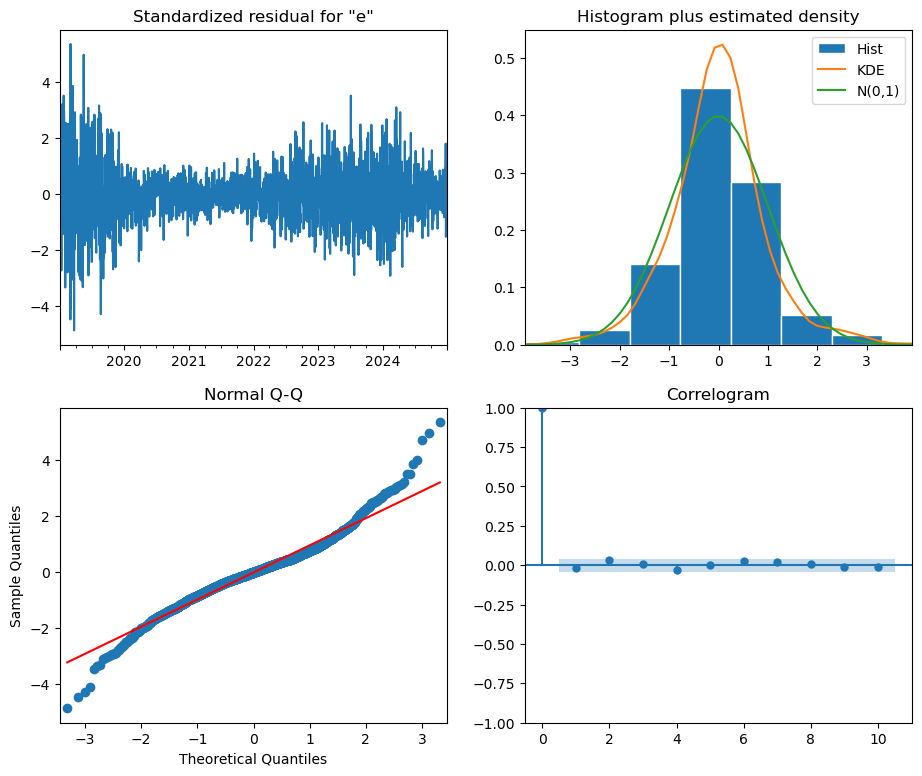

In [133]:
# Create the 4 diagnostics plots
sarimax_02_results.plot_diagnostics()
plt.show()

## Step 12: SARIMAX with Boxcox Data Transformation

The residuals are still not normally distributed so I attempt to use SARIMAX with data transformation.

In [134]:
from scipy.stats import boxcox

#Apply Box-Cox
y = Y['estimated_actual_footfall']
y_boxcox, lambda_ = boxcox(y +1)

#Put it back into DataFrame, with date index
Y_boxcox = pd.Series(y_boxcox, index=y.index, name='footfall_boxcox')

print('Estimated lambda:', lambda_)

Estimated lambda: -1.0342037580487076


In [135]:
#Get d parameter on transformed data
obtain_adf_kpss_results(Y_boxcox, 3)

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")


,d,adf_stats,p-value,is_adf_stationary,is_kpss_stationary,is_stationary
0,0,1.156295e-01,0.01,False,False,False
1,1,1.765354e-26,0.10,True,True,True
2,2,6.482393e-30,0.10,True,True,True


So d=1 for the boxcox transformed data.

In [136]:
# Take the first and seasonal differences (S=7) and drop NaNs
Y_boxcox_diff = Y_boxcox.diff().diff(7).dropna()

#Get D parameter on differenced transformed data 
obtain_adf_kpss_results(Y_boxcox_diff, 3)

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_11960\52174979.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")


,d,adf_stats,p-value,is_adf_stationary,is_kpss_stationary,is_stationary
0,0,1.705099e-26,0.1,True,True,True
1,1,0.000000e+00,0.1,True,True,True
2,2,0.000000e+00,0.1,True,True,True


So D=0. I search for the best SARIMAX parameters with the boxcox transformed data and d=1 and D=0.

In [137]:
#import pmdarima as pm

# Create auto_arima model
#model3 = pm.auto_arima(Y_boxcox, #time series
                      #seasonal=True, # is the time series seasonal
                      #m=7, # the seasonal period - one week?
                      #d=1, # non-seasonal difference order
                      #D=0, # seasonal difference order
                 	  #max_p=6, # max value of p to test 
                      #max_q=6, # max value of p to test
                      #max_P=6, # max value of P to test 
                      #max_Q=6, # max value of Q to test 
                      #information_criterion='aic', # used to select best mode
                      #trace=True, # prints the information_criterion for each model it fits
                      #error_action='ignore', # ignore orders that don't work
                      #stepwise=True, # apply an intelligent order search
                      #suppress_warnings=True) 

# Print model summary
#print(model3.summary())

**Results:**
* Best SARIMA parameters for boxcox transformed data are (0,1,0)(0,0,0)[7] , d=1 and D=0.

In [138]:
sarimax_03_model = SARIMAX(endog= Y_boxcox,
                        exog= X,
                        order=(0,1,0), 
                        seasonal_order=(0,0,0,7),
                        freq="D")
sarimax_03_results = sarimax_03_model.fit()

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [139]:
sarimax_03_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        footfall_boxcox   No. Observations:                 2192
Model:               SARIMAX(0, 1, 0)   Log Likelihood               23200.779
Date:                Tue, 13 Jan 2026   AIC                         -46385.558
Time:                        14:47:00   BIC                         -46340.021
Sample:                    01-01-2019   HQIC                        -46368.915
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
bank_hol            -2.084e-08      0.000     -0.000      1.000      -0.000       0.000
school_hol           3.014e-08      0.000      0.000      1.000      -0.000       0.000
covid               -3.104e-09   1.68e-09     -1.847      0.065    -6.4e-09     1.9e-10
temperature_2m_mean  1.035e-10    1.8e-05   5.76e-06      1.000   -3.52e-05    3.52e-05
precipitation_sum   -3.342e-10   5.51e-06  -6.07e-05      1.000   -1.08e-05    1.08e-05
wind_speed_10m_max  -4.246e-10   3.72e-06     -0.000      1.000   -7.29e-06    7.29e-06
daylight_duration    1.549e-12   1.47e-07   1.05e-05      1.000   -2.88e-07    2.88e-07
sigma2                   1e-10   4.23e-11      2.361      0.018     1.7e-11    1.83e-10
===================================================================================
Ljung-Box (L1) (Q):                 295.93   Jarque-Bera (JB):              3479.48
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.53   Skew:                             0.27
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.03e+20. Standard errors may be unstable.
"""

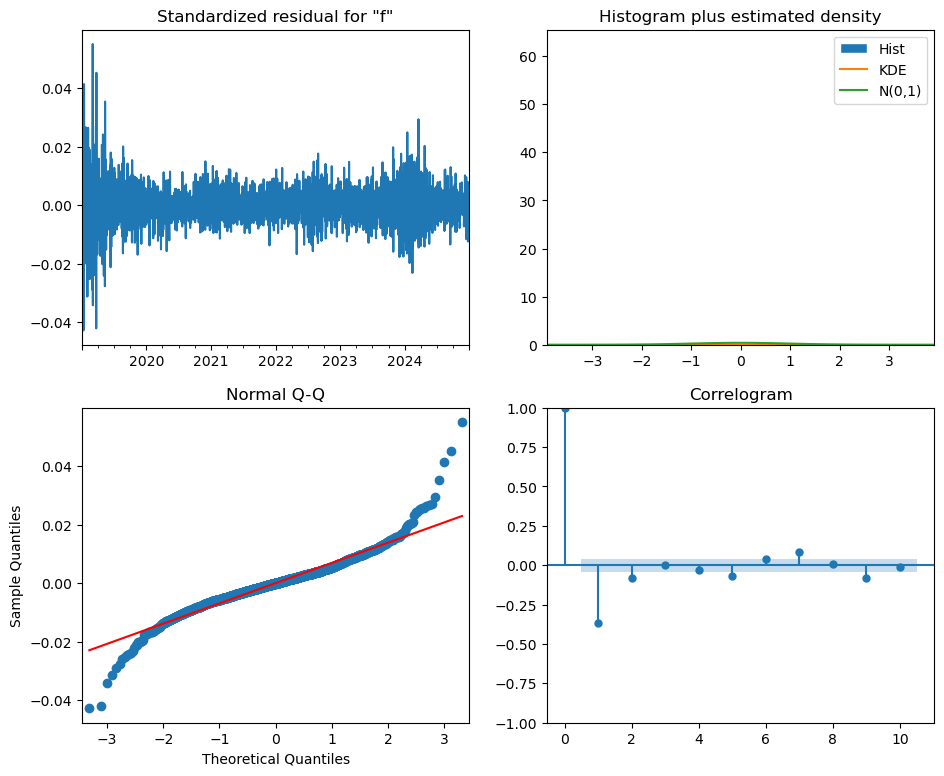

In [140]:
# Create the 4 diagnostics plots
sarimax_03_results.plot_diagnostics()
plt.show()

## Step 13: ARIMA, SARIMA, SARIMAX Forecast Comparison

I will continue using both ARIMA and SARIMA models even if I know that SARIMAX in this case is the most adequate model. The goal here is to show why SARIMAX is the most adequate.

To have a feeling on how good the chosen models are doing I will take the last 20%, i.e the last 438 days of timeseries in training dataset as validation data.

In [141]:
# Create ARIMA mean forecast
arima_pred = arima_results.get_prediction(start=-438, dynamic=True)
arima_mean = arima_pred.predicted_mean

#------------------------------------------------------------------------------------------

# Create SARIMA 01 mean forecast (manually chosen parameters)
sarima_01_pred = sarima_01_results.get_prediction(start=-438, dynamic=True)
sarima_01_mean = sarima_01_pred.predicted_mean

#------------------------------------------------------------------------------------------

# Create SARIMA 02 mean forecast (automated parameter selection)
sarima_02_pred = sarima_02_results.get_prediction(start=-438, dynamic=True)
sarima_02_mean = sarima_02_pred.predicted_mean

#------------------------------------------------------------------------------------------

# Create SARIMA 03 mean forecast (log transformed and automated parameter selection)
sarima_03_pred = sarima_03_results.get_prediction(start=-438, dynamic=True)
sarima_03_mean = sarima_03_pred.predicted_mean
#Back transform the predictions
sarima_03_mean_bt = np.exp(sarima_03_mean) - 1

#------------------------------------------------------------------------------------------

# Create SARIMAX 01 mean forecast (manual parameter selection)
sarimax_01_pred = sarimax_01_results.get_prediction(start=Y.index[-438], 
                                              end=Y.index[-1],
                                              exog= X[-438:],
                                              dynamic=True)
sarimax_01_mean = sarimax_01_pred.predicted_mean

#------------------------------------------------------------------------------------------

# Create SARIMAX 02 mean forecast (automated parameter selection)
sarimax_02_pred = sarimax_02_results.get_prediction(start=Y.index[-438], 
                                              end=Y.index[-1],
                                              exog= X[-438:],
                                              dynamic=True)
sarimax_02_mean = sarimax_02_pred.predicted_mean

#------------------------------------------------------------------------------------------

# Create SARIMAX 02 mean forecast (boxcox transformed and automated parameter selection)
sarimax_03_pred = sarimax_03_results.get_prediction(start=Y_boxcox.index[-438], 
                                              end=Y_boxcox.index[-1],
                                              exog= X[-438:],
                                              dynamic=True)
sarimax_03_mean = sarimax_03_pred.predicted_mean

#Back transform the predictions
from scipy.special import inv_boxcox
sarimax_03_mean_bt = inv_boxcox(sarimax_03_mean, lambda_) - 1

In [142]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

metrics_arima = [round(mean_absolute_error(Y[-438:],arima_mean),3), 
                 round(mean_absolute_percentage_error(Y[-438:], arima_mean),3),
                 round(root_mean_squared_error(Y[-438:], arima_mean), 3)]


metrics_sarima_01 = [round(mean_absolute_error(Y[-438:],sarima_01_mean),3), 
                       round(mean_absolute_percentage_error(Y[-438:],sarima_01_mean),3),
                 round(root_mean_squared_error(Y[-438:], sarima_01_mean), 3)]


metrics_sarima_02 = [round(mean_absolute_error(Y[-438:],sarima_02_mean),3),
                       round(mean_absolute_percentage_error(Y[-438:],sarima_02_mean),3),
                 round(root_mean_squared_error(Y[-438:], sarima_02_mean), 3)]

metrics_sarima_03 = [round(mean_absolute_error(Y[-438:],sarima_03_mean_bt),3),
                       round(mean_absolute_percentage_error(Y[-438:], sarima_03_mean_bt),3),
                 round(root_mean_squared_error(Y[-438:], sarima_03_mean), 3)]

metrics_sarimax_01 = [round(mean_absolute_error(Y[-438:],sarimax_01_mean),3),
                       round(mean_absolute_percentage_error(Y[-438:],sarimax_01_mean),3),
                 round(root_mean_squared_error(Y[-438:], sarimax_01_mean), 3)]

metrics_sarimax_02 = [round(mean_absolute_error(Y[-438:],sarimax_02_mean),3),
                       round(mean_absolute_percentage_error(Y[-438:],sarimax_02_mean),3),
                 round(root_mean_squared_error(Y[-438:], sarimax_02_mean), 3)]

metrics_sarimax_03 = [round(mean_absolute_error(Y[-438:],sarimax_03_mean_bt),3),
                       round(mean_absolute_percentage_error(Y[-438:],sarimax_03_mean_bt),3),
                 round(root_mean_squared_error(Y[-438:], sarimax_03_mean), 3)]

In [143]:
df_arima_results = pd.DataFrame({'metrics':['MAE','MAPE','RMSE'],
              'ARIMA(6,1,6)':metrics_arima, 
              'SARIMA(6,1,6)(1,0,1)7':metrics_sarima_01,
              'SARIMA(3,1,3)(1,0,1)7':metrics_sarima_02,
              'SARIMA_log (5,1,1)(6,1,1)7':metrics_sarima_03,
              'SARIMAX(6,1,6)(1,0,1)7':metrics_sarimax_01,
              'SARIMAX(3,1,3)(1,0,1)7':metrics_sarimax_02,
              'SARIMAX_boxcox (0,1,0)(0,0,0)7':metrics_sarimax_02,
             })

df_arima_results

,metrics,"ARIMA(6,1,6)","SARIMA(6,1,6)(1,0,1)7","SARIMA(3,1,3)(1,0,1)7","SARIMA_log (5,1,1)(6,1,1)7","SARIMAX(6,1,6)(1,0,1)7","SARIMAX(3,1,3)(1,0,1)7","SARIMAX_boxcox (0,1,0)(0,0,0)7"
0,MAE,74842.107,74170.597,88066.027,95941.748,87765.812,108386.616,108386.616
1,MAPE,0.125,0.124,0.147,0.154,0.145,0.178,0.178
2,RMSE,85789.755,85148.057,98809.639,627844.027,96192.216,117435.400,117435.400


**Results**: The SARIMA model using the manually selected parameters seems to be the best model considering the evaluation metrics.

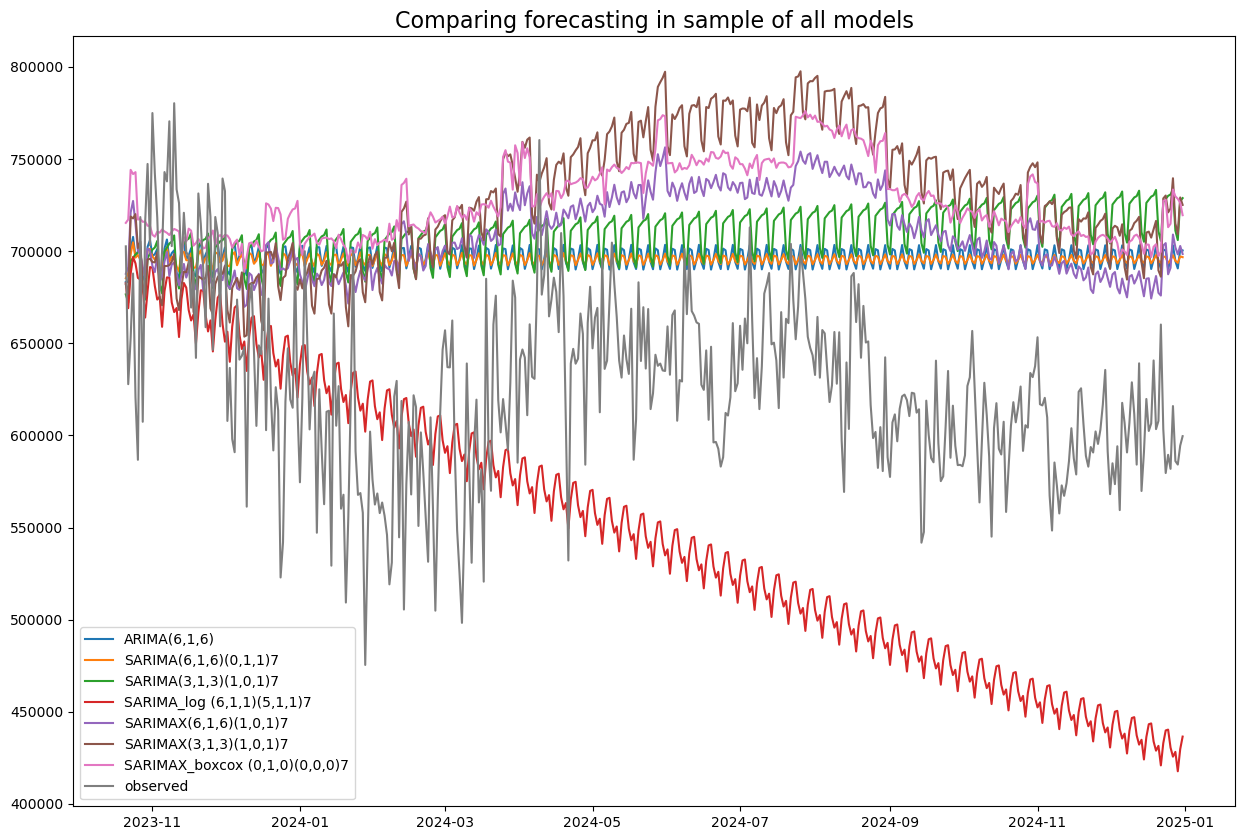

In [144]:
dates = Y.index
# Plot mean ARIMA, SARIMA and SARIMAX predictions and observed
plt.figure(figsize=(15,10))
plt.title('Comparing forecasting in sample of all models', size = 16)
plt.plot(arima_mean.index, arima_mean, label='ARIMA(6,1,6)')
plt.plot(sarima_01_mean.index, sarima_01_mean, label='SARIMA(6,1,6)(0,1,1)7')
plt.plot(sarima_02_mean.index, sarima_02_mean, label='SARIMA(3,1,3)(1,0,1)7')
plt.plot(sarima_03_mean_bt.index, sarima_03_mean_bt, label='SARIMA_log (6,1,1)(5,1,1)7')
plt.plot(sarimax_01_mean.index, sarimax_01_mean, label='SARIMAX(6,1,6)(1,0,1)7')
plt.plot(sarimax_02_mean.index, sarimax_02_mean, label='SARIMAX(3,1,3)(1,0,1)7')
plt.plot(sarimax_03_mean_bt.index, sarimax_03_mean_bt, label='SARIMAX_boxcox (0,1,0)(0,0,0)7')
plt.plot(Y[-438:], label='observed')
plt.legend()
plt.show()

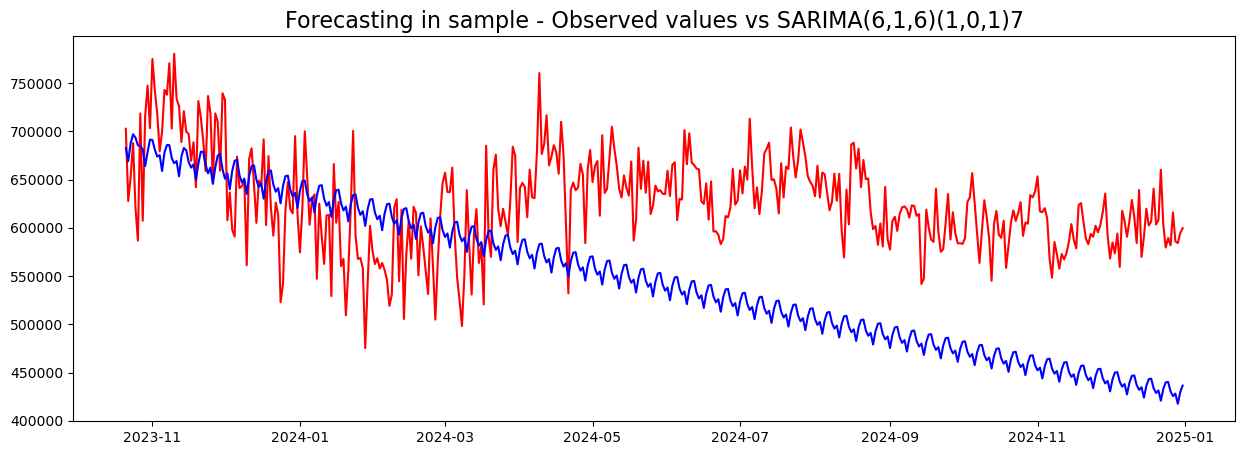

In [145]:
plt.figure(figsize=(15,5))
plt.title('Forecasting in sample - Observed values vs SARIMA(6,1,6)(1,0,1)7', size = 16)
plt.plot(Y[-438:], label='observed', color='red')
plt.plot(sarima_03_mean_bt.index, sarima_03_mean_bt, label='SARIMA(6,1,6)(1,0,1)7', color='blue')

## Conclusion

Out of all the models tested, the **SARIMA (6,1,6)(0,1,0)[7]** had the best performance. 
And this despite:
* trying to do automated parameter selection (this model has manually determined parameters)
* trying data transformations as the residuals are not normally distributed
* trying to incorporate exogenous predictors (ex: weather and bank holidays) in SARIMAX models

Thus, we choose this model to predict footfall in 2025 and 2026.


## **Important Note:** 
the evaluation metrics of this SARIMA model are also better than the Randon Forest Regression without lag-roll previously developed. **BUT** the Random Forest Regression model **with** lag-roll predictors has better evaluation metrics !

**Random Forest Regression (without lag-roll):**
* MAE: 121563.95179347113
* R2: -6.31643975226428
* MAPE: 0.20096667914901534
* RMSE: 133243.57573212564


**Random Forest Regression (with lag-roll):**
* MAE: 26628.246608442903
* R2: 0.4931481391681486
* MAPE: 0.04319957771308404
* RMSE: 35070.09167961037

## Step 14: 2025 Footfall Prediction

We start again clean by training the SARIMA model on the 2019-2024 footfall data, and then conduct predictions for 2025, allowing to compare predicted and actual values.

In [ ]:
#Load training footfall (2019-2024) data again
data_19_24 = pd.read_csv(r"footfall_cleaned_19_24")
data_19_24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2192 non-null   int64  
 1   datestamp                          2192 non-null   object 
 2   estimated_actual_footfall          2192 non-null   float64
 3   estimated_actual_footfall_rolling  2192 non-null   int64  
 4   year                               2192 non-null   int64  
 5   month                              2192 non-null   int64  
 6   monthday                           2192 non-null   int64  
 7   weekday                            2192 non-null   int64  
 8   week_of_year                       2192 non-null   int64  
 9   Sin_weekday                        2192 non-null   float64
 10  Cos_weekday                        2192 non-null   float64
 11  Sin_monthday                       2192 non-null   float

In [147]:
#Keep only the columns of interest for analysis
data_19_24  = data_19_24[['datestamp', 'estimated_actual_footfall']]
#Set the datestamp as the index
data_19_24['datestamp'] = pd.to_datetime(data_19_24['datestamp'])
data_19_24.set_index('datestamp', inplace=True)
data_19_24.head()

,estimated_actual_footfall
datestamp,
2019-01-01,530996.0
2019-01-02,568621.0
2019-01-03,606939.0
2019-01-04,508695.0
2019-01-05,468546.0


In [163]:
data_19_24.isna().sum()

estimated_actual_footfall    0
dtype: int64

In [148]:
#Fit SARIMA model on 2019-2024 footfall data
sarima_model = SARIMAX(data_19_24, order=(6,1,6), seasonal_order=(1,0,1,7), freq='D')
sarima_results = sarima_model.fit()

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [149]:
#Create forecast for the next 278 days (number of days in 2025 currently available)
# Create SARIMA mean forecast
sarima_pred = sarima_results.get_forecast(steps=278)
sarima_mean = sarima_pred.predicted_mean
sarima_mean

2025-01-01    589448.515180
2025-01-02    594758.587328
2025-01-03    602808.008795
2025-01-04    594748.538318
2025-01-05    590788.884636
                  ...      
2025-10-01    591854.399145
2025-10-02    595155.796082
2025-10-03    599940.226467
2025-10-04    594524.880751
2025-10-05    592158.805817
Freq: D, Name: predicted_mean, Length: 278, dtype: float64

In [ ]:
#Get data to make prediction on -> the 2025 footfall data
#Load training footfall (2019-2024) data
data_2025 = pd.read_csv(r"footfall_cleaned_2025")
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         278 non-null    int64  
 1   datestamp                          278 non-null    object 
 2   estimated_actual_footfall          114 non-null    float64
 3   estimated_actual_footfall_rolling  278 non-null    int64  
 4   year                               278 non-null    int64  
 5   month                              278 non-null    int64  
 6   monthday                           278 non-null    int64  
 7   weekday                            278 non-null    int64  
 8   week_of_year                       278 non-null    int64  
 9   Sin_weekday                        278 non-null    float64
 10  Cos_weekday                        278 non-null    float64
 11  Sin_monthday                       278 non-null    float64

In [151]:
#Keep only the columns of interest for analysis
data_2025  = data_2025[['datestamp', 'estimated_actual_footfall']]
#Set the datestamp as the index
data_2025['datestamp'] = pd.to_datetime(data_2025['datestamp'])
data_2025.set_index('datestamp', inplace=True)
data_2025.tail()

,estimated_actual_footfall
datestamp,
2025-10-02,NaN
2025-10-03,NaN
2025-10-04,NaN
2025-10-05,NaN
2025-10-06,NaN


In [152]:
#Combine actual and predicted 2025 footfall(
predictions_2025 = data_2025.join(sarima_mean.rename('sarima_forecast'))
predictions_2025.head()

,estimated_actual_footfall,sarima_forecast
datestamp,,
2025-01-01,577601.0,589448.515180
2025-01-02,607459.0,594758.587328
2025-01-03,599189.0,602808.008795
2025-01-04,624713.0,594748.538318
2025-01-05,553875.0,590788.884636


In [153]:
#Calculate the percentage increase
predictions_2025['Percentage_Increase'] = ((predictions_2025['estimated_actual_footfall'] - predictions_2025['sarima_forecast']) / abs(predictions_2025['sarima_forecast'])) * 100

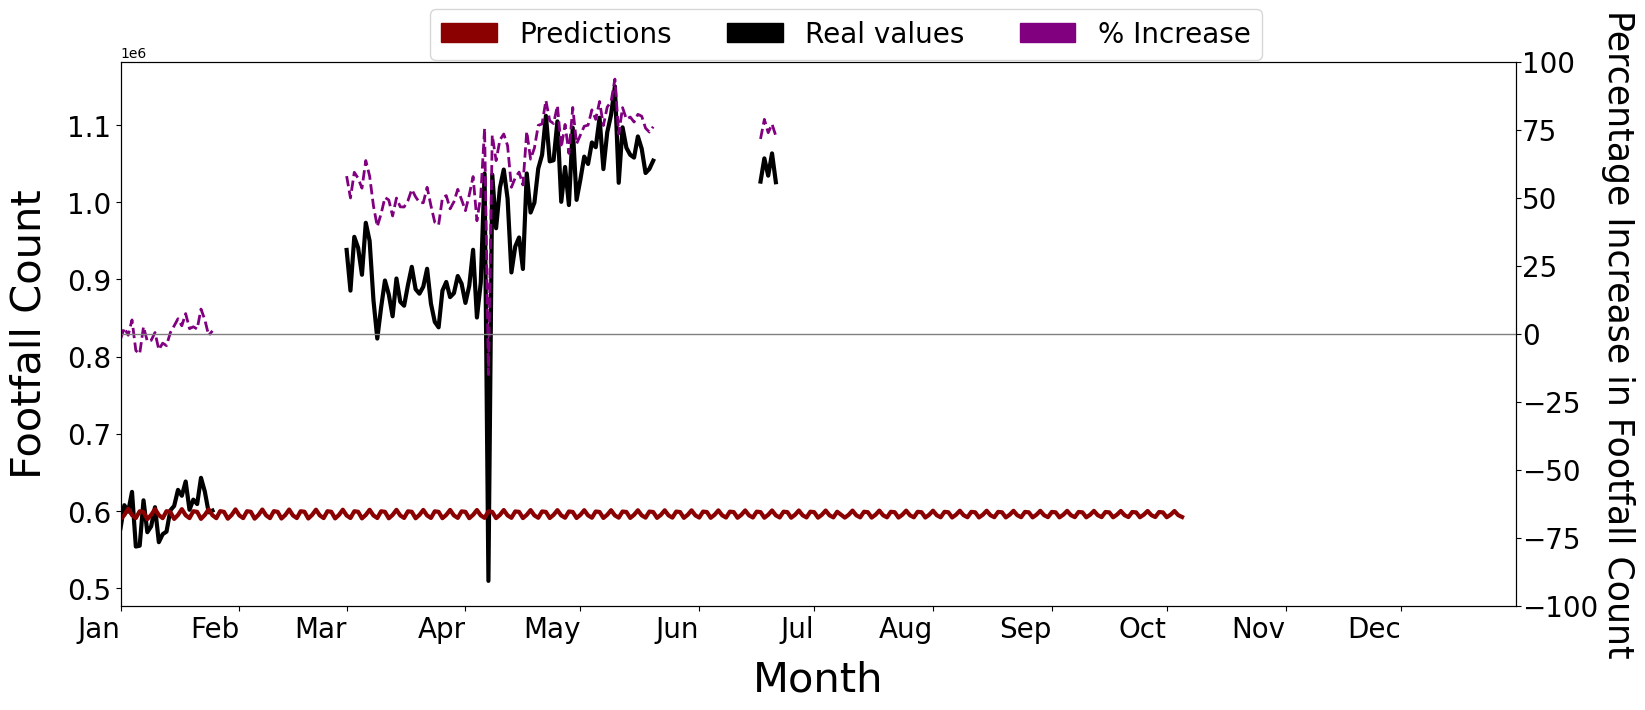

In [156]:
#Plot actual footfall, predicted footfall, and percentage increase between the two for comparison
import matplotlib.patches as mpatches
import matplotlib.dates as mdates


include_percent_increase = True

fig, ax = plt.subplots(figsize = (18,8), sharex = True)

#Plot actual and predicted footfall
predictions_2025.plot(y='estimated_actual_footfall', ax=ax, color='black', linewidth=3, legend =False)
predictions_2025.plot(y='sarima_forecast', ax=ax, color='darkred', linewidth=3, legend =False)

#Plot percentage increase on secondary axis
if include_percent_increase==True:
    ax2 = ax.twinx()
    predictions_2025.plot(y='Percentage_Increase', ax=ax2, color='purple', linewidth=2, legend =False, linestyle = 'dashed')
    ax2.set_ylabel('Percentage Increase in Footfall Count', fontsize=25, rotation=270, labelpad=27)
    ax2.tick_params(axis='both', which='major', labelsize=20, pad=1)
    ax2.set_ylim(-100,100)

#Set x axis to show month names, and tick parameters
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
#Force x axis to start in Jan to Dec
ax.set_xlim([pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31')])
ax.tick_params(axis='x', labelsize=20, rotation=0)
ax.tick_params(axis='y', labelsize=20)

#Set labels of axes
ax.set_xlabel('Month', fontsize = 30, labelpad=12)
ax.set_ylabel ('Footfall Count',fontsize=30, labelpad=12)

#Legend
colors_leg = ['darkred', 'black', 'purple']
texts = ['Predictions', 'Real values','% Increase'] 
patches = [ mpatches.Patch(color=colors_leg[i], label="{:s}".format(texts[i]) ) for i in range(len(texts)) ]    

plt.axhline(y = 0, color = 'grey', linestyle = '-', linewidth=1)     
plt.legend(handles=patches, bbox_to_anchor=(0.52, 1.05), loc='center', ncol=3, prop={'size': 20});

plt.show()

In [155]:
#Get yearly average of the %increase
predictions_2025.describe()

,estimated_actual_footfall,sarima_forecast,Percentage_Increase
count,1.140000e+02,277.000000,114.000000
mean,8.912255e+05,595736.640307,49.606494
std,1.786693e+05,3694.665650,29.959028
min,5.093770e+05,589332.996056,-15.029105
25%,8.464572e+05,591815.746597,41.083331
50%,9.137295e+05,594984.608192,53.933076
75%,1.041287e+06,598954.064528,75.212255
max,1.150276e+06,602808.008795,93.570714


## Step 15: 2026 Footfall Prediction

This time we train the model on the whole dataset from 2019 to 2025 and predict footfall for the whole of 2026.

In [ ]:
#Load whole footfall (2019-2025) data
data_19_25 = pd.read_csv(r"footfall_cleaned")
data_19_25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2470 non-null   int64  
 1   datestamp                          2470 non-null   object 
 2   estimated_actual_footfall          2306 non-null   float64
 3   estimated_actual_footfall_rolling  2470 non-null   int64  
 4   year                               2470 non-null   int64  
 5   month                              2470 non-null   int64  
 6   monthday                           2470 non-null   int64  
 7   weekday                            2470 non-null   int64  
 8   week_of_year                       2470 non-null   int64  
 9   Sin_weekday                        2470 non-null   float64
 10  Cos_weekday                        2470 non-null   float64
 11  Sin_monthday                       2470 non-null   float

In [160]:
#Keep only the columns of interest for analysis
data_19_25  = data_19_25[['datestamp', 'estimated_actual_footfall']]
#Set the datestamp as the index
data_19_25['datestamp'] = pd.to_datetime(data_19_25['datestamp'])
data_19_25.set_index('datestamp', inplace=True)
data_19_25.head()

,estimated_actual_footfall
datestamp,
2019-01-01,530996.0
2019-01-02,568621.0
2019-01-03,606939.0
2019-01-04,508695.0
2019-01-05,468546.0


In [172]:
#Ensure that there is row for each day even if have NaNs
data_19_25 = data_19_25.asfreq('D')
data_19_25.tail(100)

,estimated_actual_footfall
datestamp,
2025-06-29,NaN
2025-06-30,NaN
2025-07-01,NaN
2025-07-02,NaN
2025-07-03,NaN
...,...
2025-10-02,NaN
2025-10-03,NaN
2025-10-04,NaN


In [162]:
data_19_25.isna().sum()

estimated_actual_footfall    164
dtype: int64

In [173]:
#I try to find the last date in 2025 with footfall
data_19_25_NA = data_19_25.dropna(subset=['estimated_actual_footfall'])
data_19_25_NA.tail()

,estimated_actual_footfall
datestamp,
2025-06-17,1026856.0
2025-06-18,1056894.0
2025-06-19,1034529.0
2025-06-20,1063359.0
2025-06-21,1026016.0


So the last day in 2025 with a footfall record is the 21st of June. I drop rows after this date as they don't provide any information for model training.

In [174]:
data_19_25 = data_19_25.loc[:'2025-06-21']

In [175]:
#Fit SARIMA model on 2019-2024 footfall data
sarima_model = SARIMAX(data_19_25, order=(6,1,6), seasonal_order=(1,0,1,7), freq='D')
sarima_results = sarima_model.fit()

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [177]:
data_19_25.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2364 entries, 2019-01-01 to 2025-06-21
Freq: D
Data columns (total 1 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   estimated_actual_footfall  2306 non-null   float64
dtypes: float64(1)
memory usage: 36.9 KB


In [179]:
#Create forecast for the next 558 days (193 days in 2025 currently missing in 2025 + 365 days in 2026)
# Create SARIMA mean forecast
sarima_pred = sarima_results.get_forecast(steps=558)
sarima_mean = sarima_pred.predicted_mean
sarima_mean

2025-06-22    1.029357e+06
2025-06-23    1.036415e+06
2025-06-24    1.039751e+06
2025-06-25    1.030187e+06
2025-06-26    1.038066e+06
                  ...     
2026-12-27    1.033452e+06
2026-12-28    1.037832e+06
2026-12-29    1.039434e+06
2026-12-30    1.034375e+06
2026-12-31    1.035000e+06
Freq: D, Name: predicted_mean, Length: 558, dtype: float64

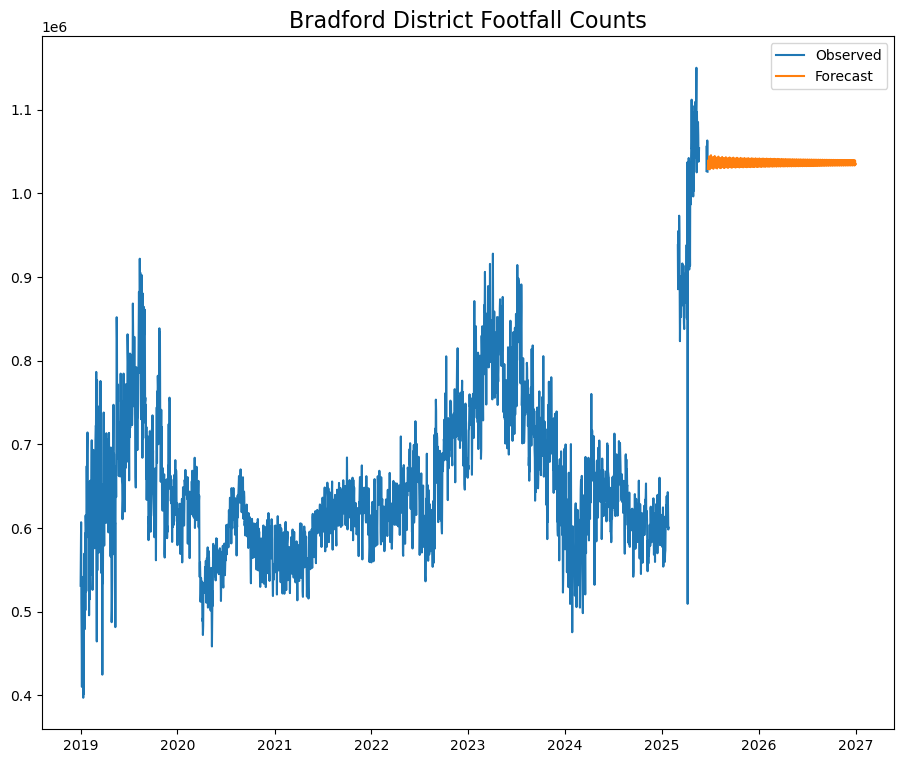

In [180]:
#Plot known data and forecast
plt.title("Bradford District Footfall Counts", size =16)
plt.plot(data_19_25, label='Observed')
plt.plot(sarima_mean.index, sarima_mean, label='Forecast')
plt.legend()
plt.show()

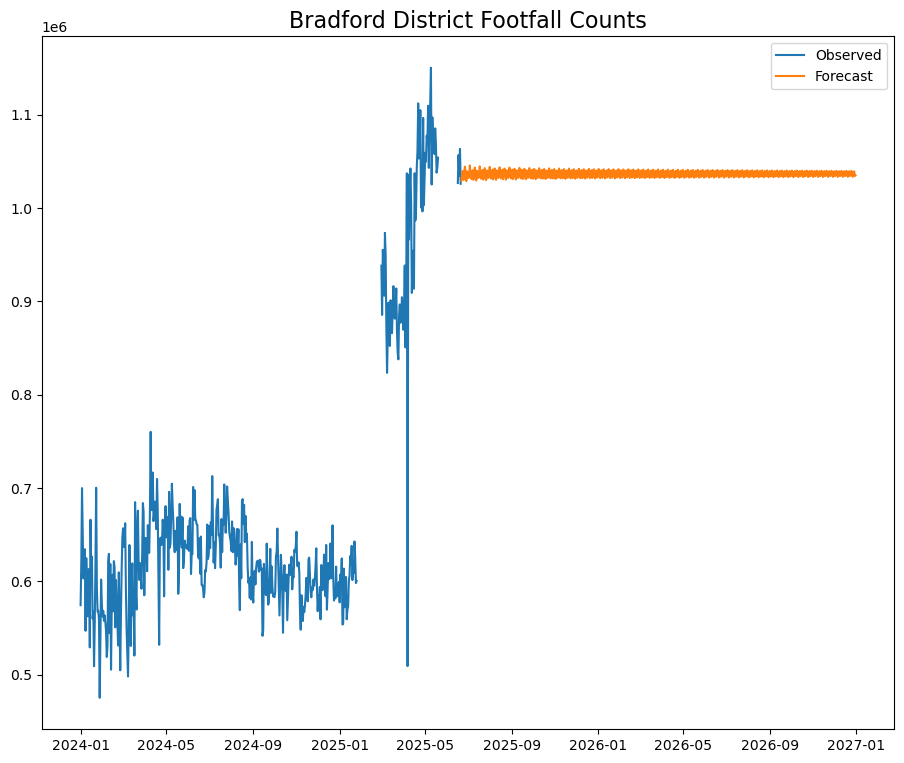

In [181]:
#Plot known data and forecast
plt.title("Bradford District Footfall Counts", size =16)
plt.plot(data_19_25['2024':], label='Observed')
plt.plot(sarima_mean.index, sarima_mean, label='Forecast')
plt.legend()
plt.show()